In [1]:
from collections import Counter
import pickle
import os
from pathlib import Path
from pprint import pprint
import re
import sys

from gensim.models import Word2Vec as GensimWord2Vec
import matplotlib.pyplot as plt
import pandas as pd
from nltk.corpus import stopwords
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

%config InlineBackend.figure_format = 'retina'

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURE_CACHE_DIR = PROCESSED_DATA_DIR / "features"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import features
import models
import plotting
import preprocessing
from preprocessing import (
    ensure_nltk_resource,
    lemmatize_text,
    lowercase_text,
    preprocess_text,
    regex_clean,
    remove_stopwords,
    stem_text,
)


/Users/mehmet/src/text_mining_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")


# Financial Tweet Sentiment Workflow

This notebook is the single end-to-end project artifact for exploration, splitting, preprocessing, and feature engineering.

## Table of Contents

- [1. Data Exploration](#1-data-exploration)
  - [1.1 Class Balance and Dataset Preview](#11-class-balance-and-dataset-preview)
  - [1.2 Dataset Dimensions and Schema](#12-dataset-dimensions-and-schema)
  - [1.3 Tweet Length Features](#13-tweet-length-features)
  - [1.4 Tweet Length by Sentiment](#14-tweet-length-by-sentiment)
  - [1.5 Frequent Terms by Sentiment](#15-frequent-terms-by-sentiment)
  - [1.6 Ticker Symbol Features](#16-ticker-symbol-features)
  - [1.7 URL and Mention Features](#17-url-and-mention-features)
- [2. Train/Validation Split](#2-trainvalidation-split)
  - [2.1 Stratified Validation Split](#21-stratified-validation-split)
- [3. Text Preprocessing](#3-text-preprocessing)
  - [3.1 Preprocessing Resources and Stopwords](#31-preprocessing-resources-and-stopwords)
  - [3.2 Original Cleaning Pipeline](#32-original-cleaning-pipeline)
  - [3.3 Lemmatization and Stemming Variants](#33-lemmatization-and-stemming-variants)
  - [3.4 Preprocessing Quality Assessment](#34-preprocessing-quality-assessment)
  - [3.5 Preprocessing Combination Benchmark](#35-preprocessing-combination-benchmark)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1 Feature Inputs and Benchmark Helper](#41-feature-inputs-and-benchmark-helper)
  - [4.2 Bag of Words and TF-IDF](#42-bag-of-words-and-tf-idf)
  - [4.3 Word2Vec Embeddings](#43-word2vec-embeddings)
  - [4.4 FinBERT Transformer Encoder Embeddings](#44-finbert-transformer-encoder-embeddings)
  - [4.5 Feature Engineering Results](#45-feature-engineering-results)
- [5. Classification Models](#5-classification-models)
  - [5.1 Model Benchmark Design](#51-model-benchmark-design)
  - [5.2 Traditional ML Classifiers](#52-traditional-ml-classifiers)
  - [5.3 Transformer Encoder Classifiers](#53-transformer-encoder-classifiers)
- [6. Evaluation and Analysis](#6-evaluation-and-analysis)
  - [6.1 Final Model Comparison](#61-final-model-comparison)
  - [6.2 Precision, Recall, and F1 by Class](#62-precision-recall-and-f1-by-class)
  - [6.3 Interpretation in Financial Sentiment Context](#63-interpretation-in-financial-sentiment-context)
  - [6.4 Final Model Selection](#64-final-model-selection)
- [Extra Credit: Advanced Transformer Models](#--extra-credit-advanced-transformer-models--)
  - [Sentence-BERT Encoder Embeddings](#sentence-bert-encoder-embeddings)
  - [RoBERTa Encoder Embeddings](#roberta-encoder-embeddings)
  - [Decoder-Only LLM Classification](#decoder-only-llm-classification)
  - [Extra-Credit Summary](#extra-credit-summary)


# 1. Data Exploration


## 1.1 Class Balance and Dataset Preview

Review the sentiment proportions and inspect the first training examples before deriving features.


In [3]:
# --- Class proportions --- #
print(train["label"].value_counts(normalize=True))

label
2    0.647386
1    0.201509
0    0.151106
Name: proportion, dtype: float64


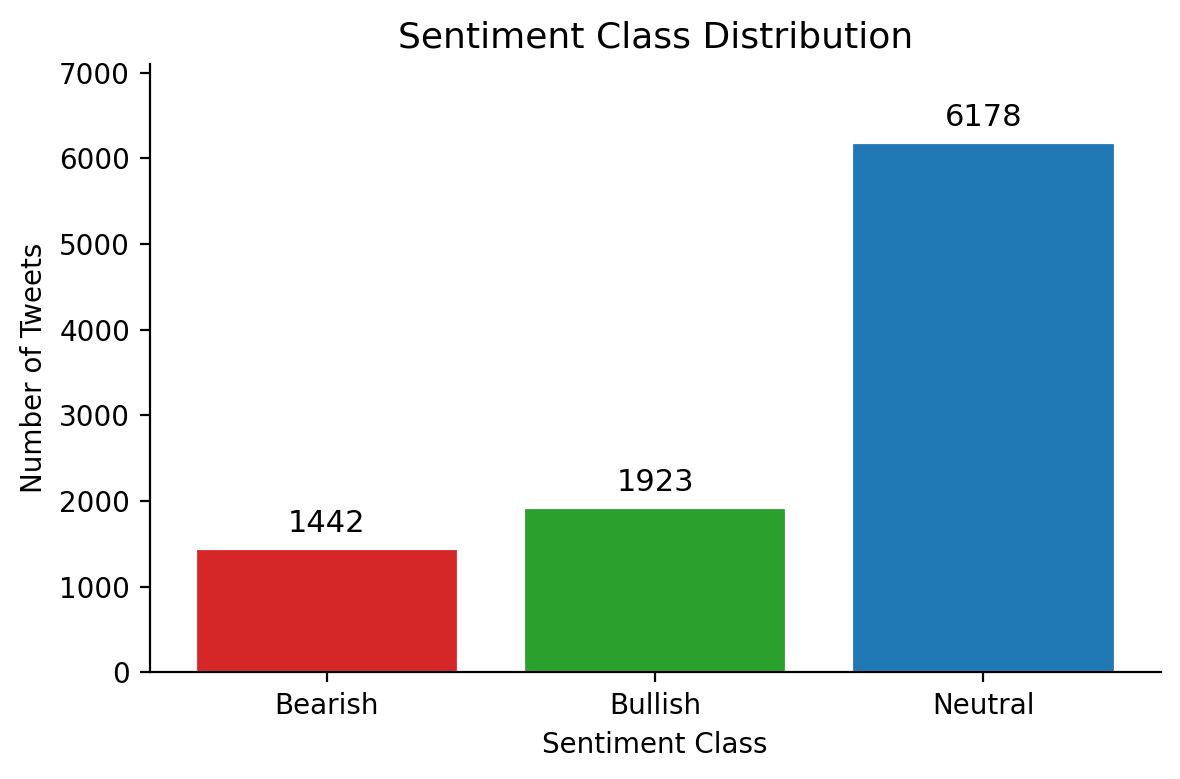

In [4]:
# --- Class distribution bar chart --- #
label_names_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
label_counts = train["label"].value_counts().sort_index()
label_labels = [label_names_map[i] for i in label_counts.index]
colors = ["#d62728", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_labels, label_counts.values, color=colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11)
ax.set_title("Sentiment Class Distribution", fontsize=13)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Number of Tweets")
ax.set_ylim(0, label_counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The bar chart above confirms the class imbalance identified in the proportions: Neutral tweets dominate the dataset at over 6,000 samples, while Bearish and Bullish are much smaller minority classes. This imbalance motivates the use of macro-averaged metrics over plain accuracy throughout the project.

In [5]:
train.head(10)

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


## 1.2 Dataset Dimensions and Schema

Confirm the train/test dimensions, column types, and missing-value status.


In [6]:
print("Dimensions of train dataset:", train.shape)
print("Dimensions of test dataset:", test.shape)

Dimensions of train dataset: (9543, 2)
Dimensions of test dataset: (2388, 2)


In [7]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 149.2 KB
None


## 1.3 Tweet Length Features

Create character and word length features to understand the basic shape of the corpus.


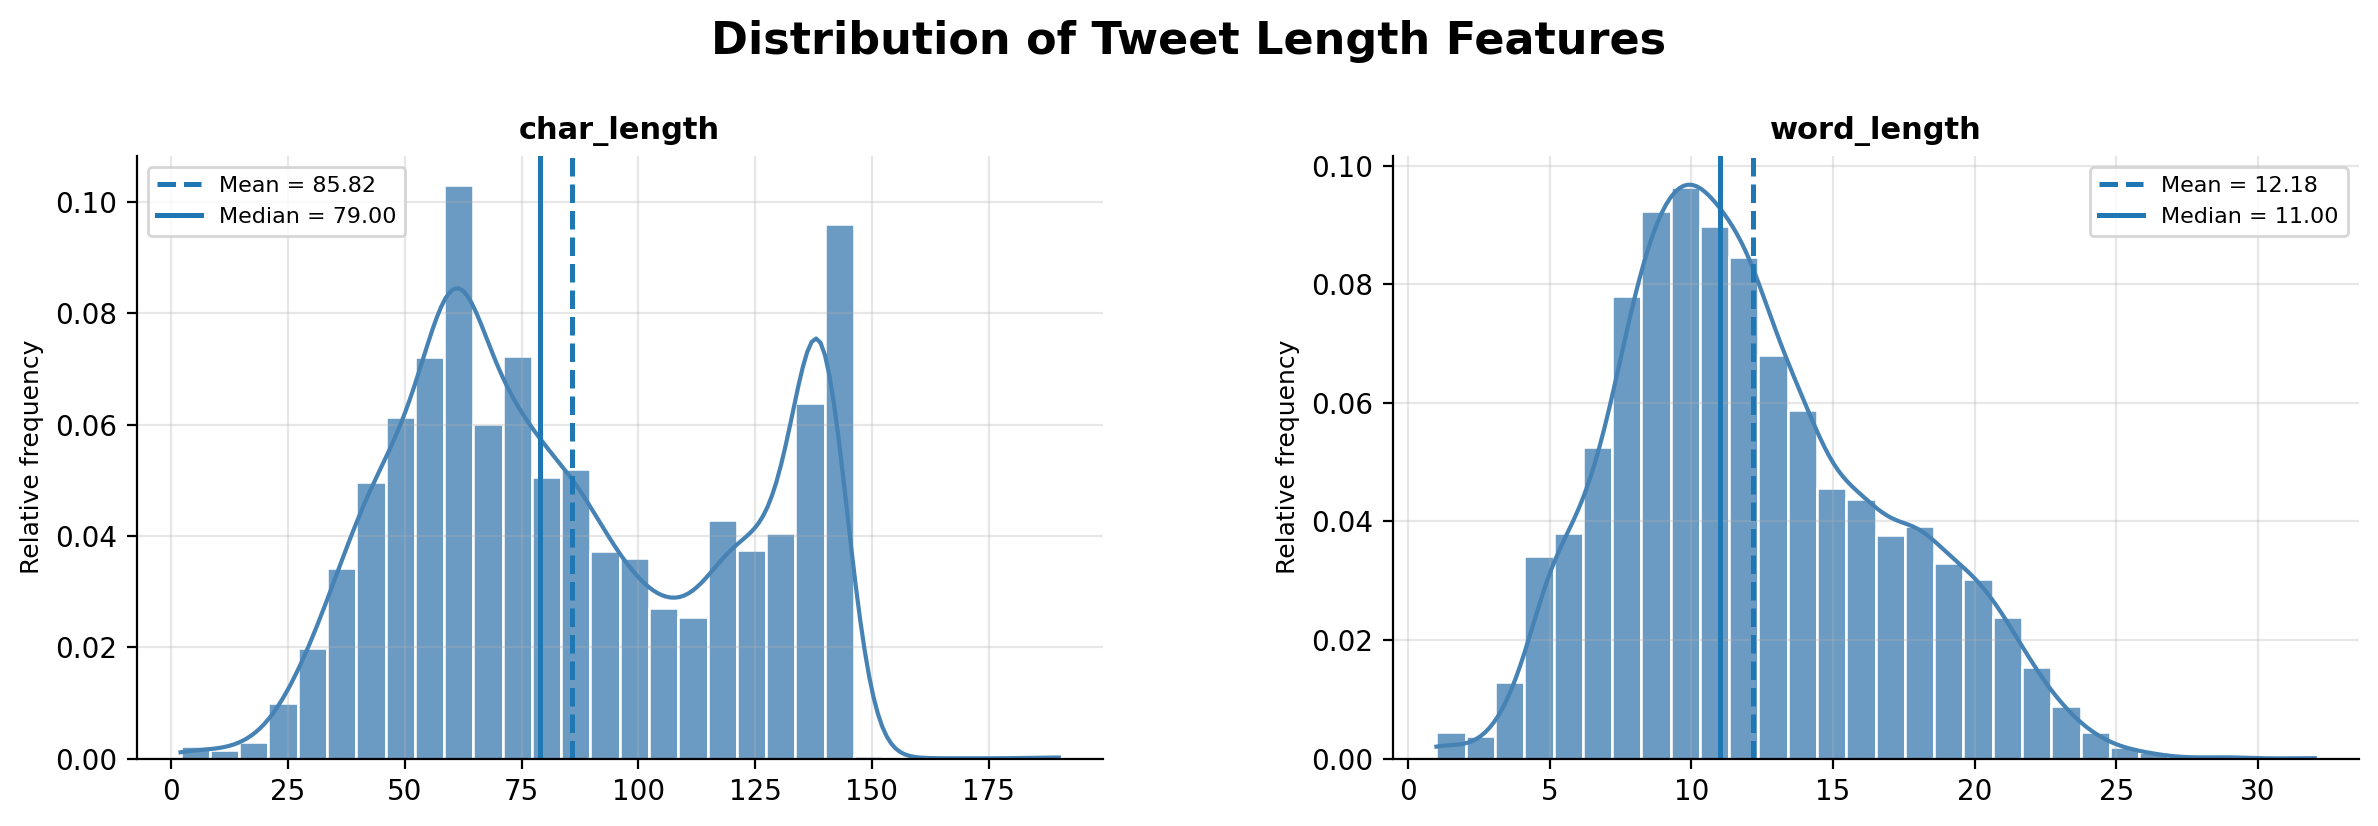

Skewness:
word_length    0.453958
char_length    0.217022
dtype: float64


In [8]:
# --- Create text-length features once for EDA --- #
eda_train = train.assign(
    char_length=train["text"].str.len(),
    word_length=train["text"].str.split().str.len(),
)

numeric_cols = ["char_length", "word_length"]

fig, axes = plotting.plot_numeric_distributions(
    eda_train,
    numeric_cols,
    title="Distribution of Tweet Length Features",
)
fig.savefig(
    FIGURES_DIR / "tweet_length_distributions.png", dpi=200, bbox_inches="tight"
)
plt.show()

print("Skewness:")
print(eda_train[numeric_cols].skew().sort_values(ascending=False))


The distributions of tweet length measured in both characters and words indicate that the corpus is predominantly composed of short texts, with a median length of 79 characters and 11 words per tweet. This finding is consistent with the nature of financial tweets, which frequently resemble concise news headlines, analyst recommendations, or short market updates. Both distributions exhibit a slight positive skew, as evidenced by the mean values exceeding the corresponding medians and further supported by the skewness coefficients of 0.217 for character length and 0.454 for word length. These values indicate only a moderate departure from symmetry, suggesting that while the corpus contains some longer tweets, they represent a relatively small proportion of the observations. Consequently, most tweets remain concentrated around the central region of the distributions, with only a limited number of messages contributing to the right tail and increasing the average tweet length.
Moreover, an additional observation can be made regarding the character-length distribution, which appears to display a bimodal structure. One concentration of tweets is observed around 60–80 characters, while a second concentration occurs around 130–145 characters. This pattern may indicate the coexistence of different types of financial tweets within the corpus, such as brief market commentary and longer headline-style messages containing additional information, ticker symbols, hashtags, or links.


## 1.4 Tweet Length by Sentiment

Compare length distributions across Bearish, Bullish, and Neutral labels.


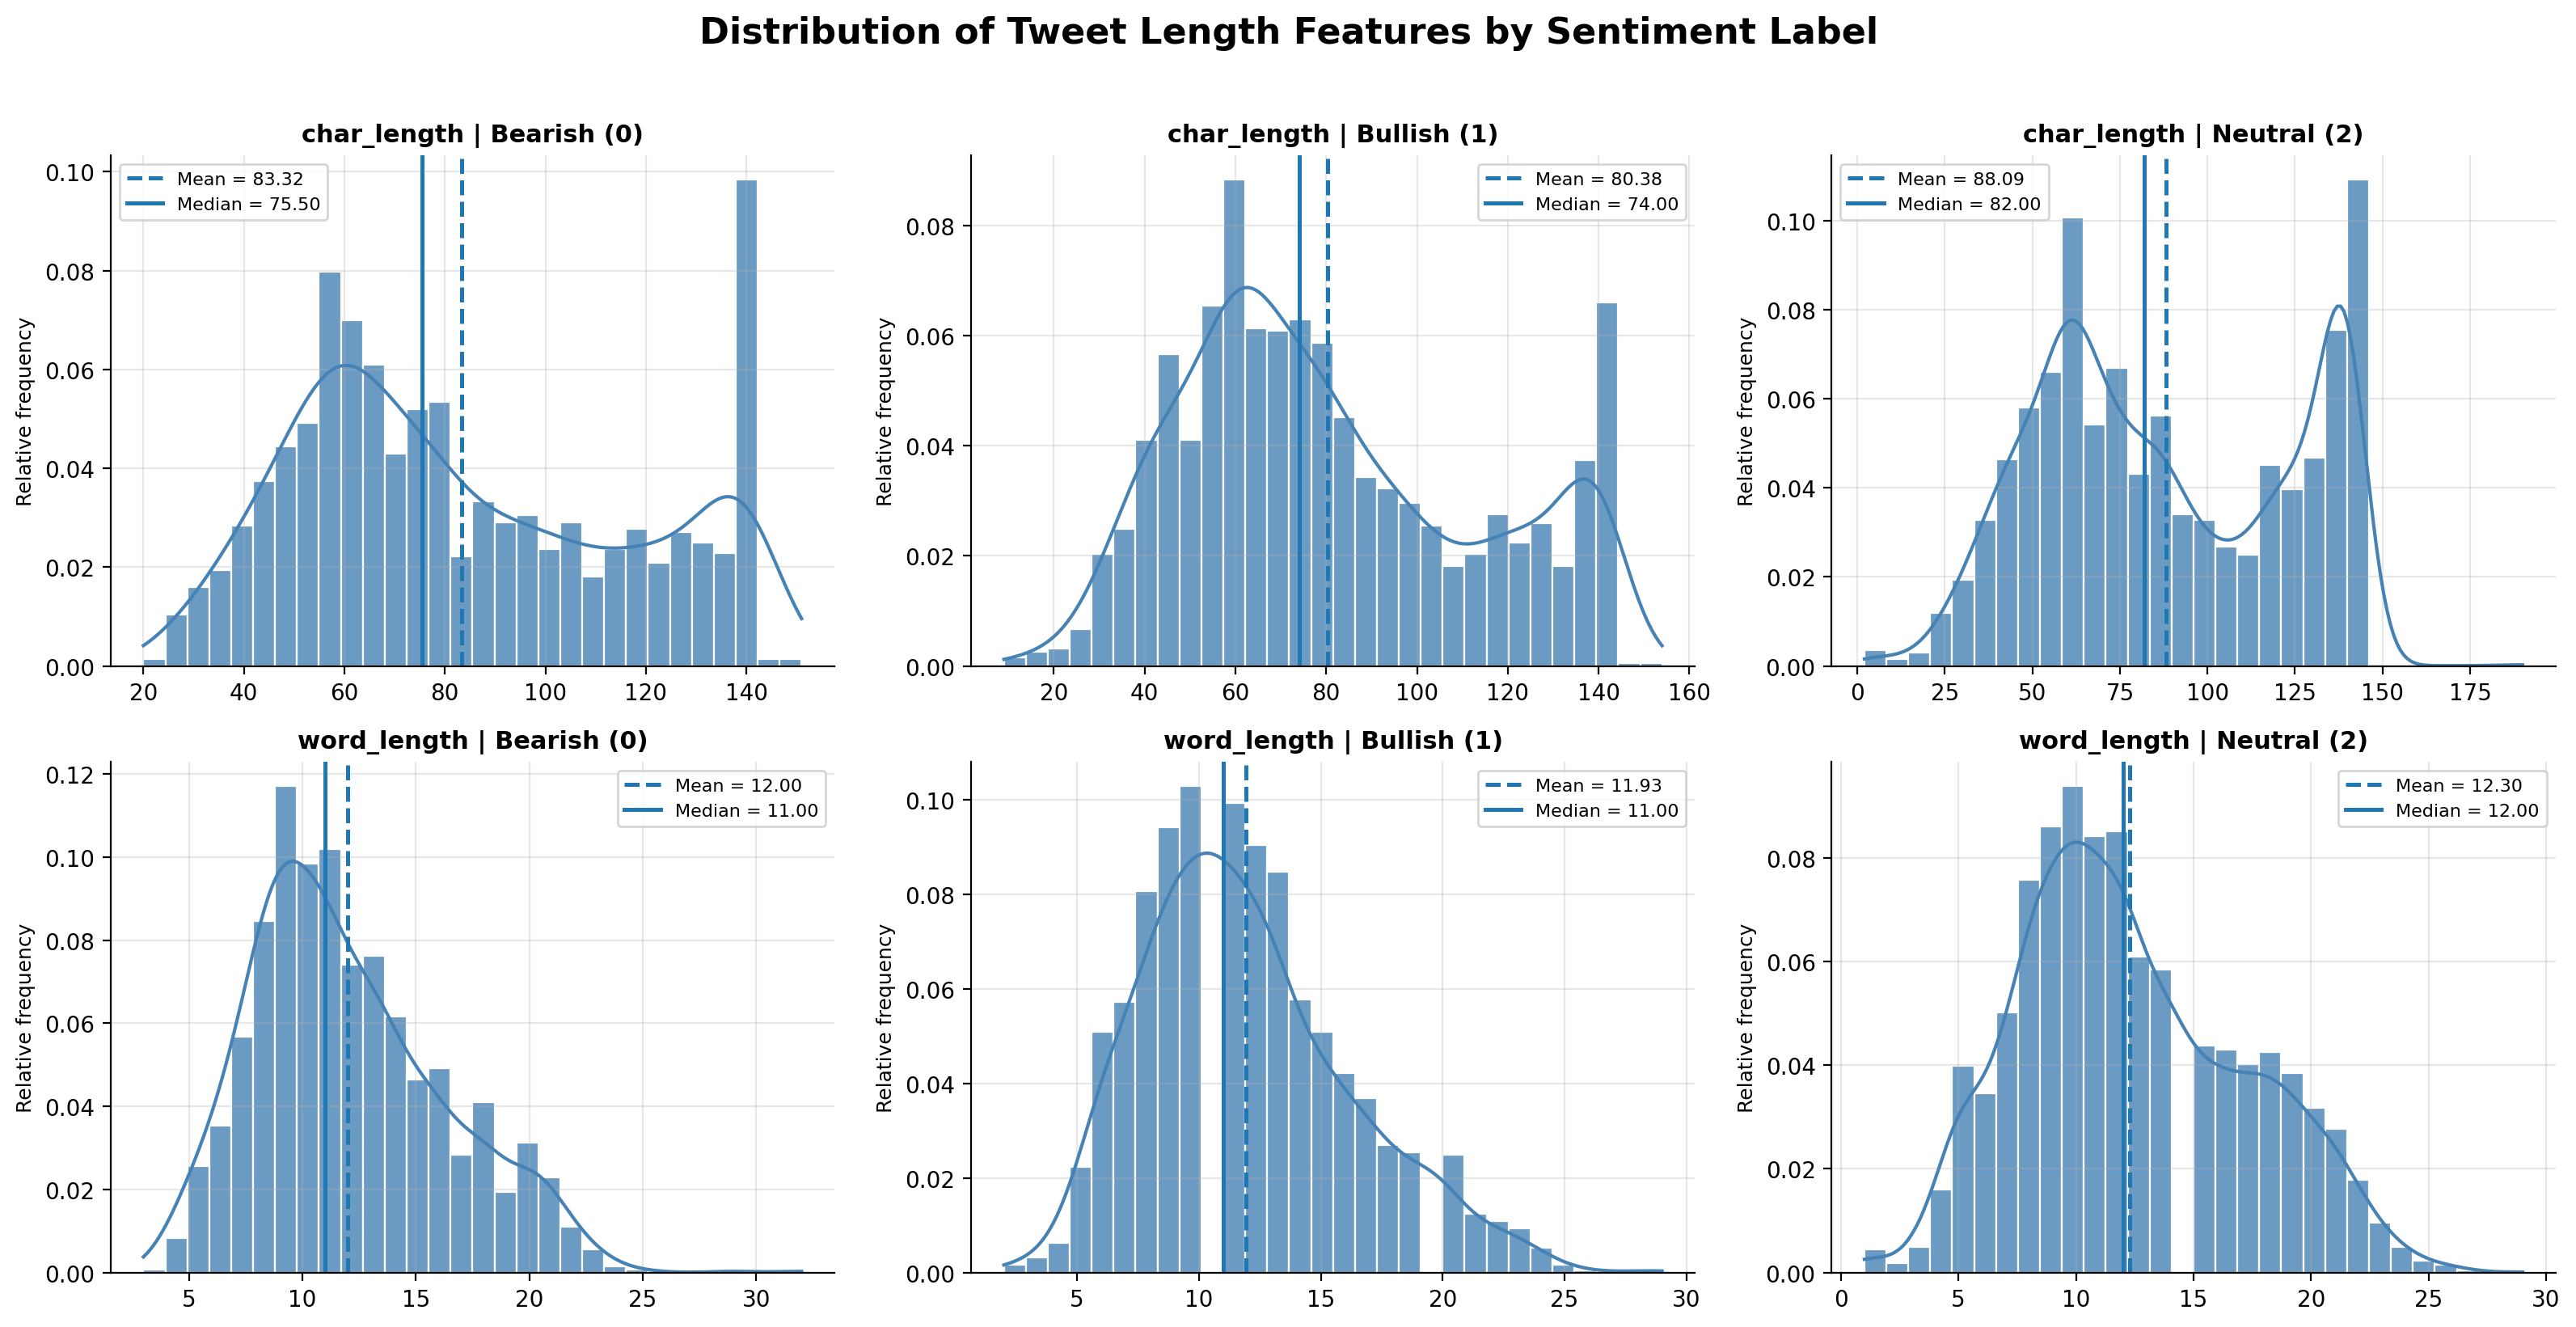

In [9]:
length_cols = ["char_length", "word_length"]

fig, axes = plotting.plot_numeric_distributions_by_label(
    eda_train,
    length_cols,
    label_col="label",
    title="Distribution of Tweet Length Features by Sentiment Label",
)
fig.savefig(FIGURES_DIR / "tweet_length_by_sentiment.png", dpi=200, bbox_inches="tight")
plt.show()


To further investigate whether tweet length varies across sentiment categories, the distributions of character length and word length were examined separately for Bearish, Bullish, and Neutral tweets. Overall, the results reveal a high degree of similarity across the three sentiment classes. The mean and median values remain relatively stable, with average character lengths ranging from approximately 80 to 88 characters and average word counts ranging from 12 to 12.3 words. These findings suggest that tweet length is largely independent of sentiment and is therefore unlikely to serve as a strong predictive feature on its own.

The distributions of character length exhibit a similar shape across all sentiment classes, including the bimodal pattern previously observed in the overall corpus. In each category, one concentration of tweets appears around 60–80 characters, while a second concentration is observed near 130–145 characters. The persistence of this structure across Bearish, Bullish, and Neutral tweets indicates that the bimodality is more likely related to different styles of financial communication than to sentiment itself. For example, both positive and negative market commentary may be expressed either as short analyst statements or as longer headline-style messages containing additional contextual information.

A comparable pattern is observed for word length. All three sentiment classes display positively skewed distributions centred around 10–12 words per tweet. While Neutral tweets appear marginally longer on average than Bearish and Bullish tweets, the differences are relatively small and do not indicate a substantial separation between classes. The considerable overlap among the distributions further suggests that sentiment classification cannot be reliably achieved through length-based features alone.

Taken together, these results indicate that structural characteristics such as tweet length provide limited discriminatory power for the sentiment classification task. Consequently, successful classification is expected to depend primarily on the semantic content of the tweets rather than on simple quantitative measures of text length.


## 1.5 Frequent Terms by Sentiment

Inspect frequent terms by label to identify vocabulary-level sentiment signals.


In [10]:
for label in sorted(train["label"].unique()):
    subset = train.query("label == @label")

    words = " ".join(subset["text"]).lower().split()

    print(f"Label {label}")
    pprint(Counter(words).most_common(20))


Label 0
[('to', 378),
 ('the', 316),
 ('in', 263),
 ('of', 232),
 ('on', 222),
 ('-', 210),
 ('as', 174),
 ('after', 171),
 ('a', 166),
 ('at', 140),
 ('stock', 130),
 ('for', 130),
 ('down', 127),
 ('and', 121),
 ('from', 102),
 ('is', 102),
 ('by', 93),
 ('are', 92),
 ('misses', 85),
 ('u.s.', 79)]
Label 1
[('to', 488),
 ('on', 386),
 ('the', 344),
 ('-', 317),
 ('in', 298),
 ('up', 255),
 ('stock', 231),
 ('a', 222),
 ('for', 209),
 ('at', 208),
 ('of', 189),
 ('as', 170),
 ('after', 165),
 ('beats', 161),
 ('and', 150),
 ('price', 132),
 ('from', 126),
 ('by', 125),
 ('target', 116),
 ('shares', 110)]
Label 2
[('the', 1836),
 ('to', 1759),
 ('of', 1239),
 ('in', 1017),
 ('a', 923),
 ('for', 872),
 ('-', 863),
 ('on', 747),
 ('and', 740),
 ('is', 655),
 ('with', 363),
 (':', 343),
 ('results', 307),
 ('at', 294),
 ('#stock', 283),
 ('new', 282),
 ('as', 261),
 ('are', 246),
 ('this', 244),
 ('earnings', 239)]


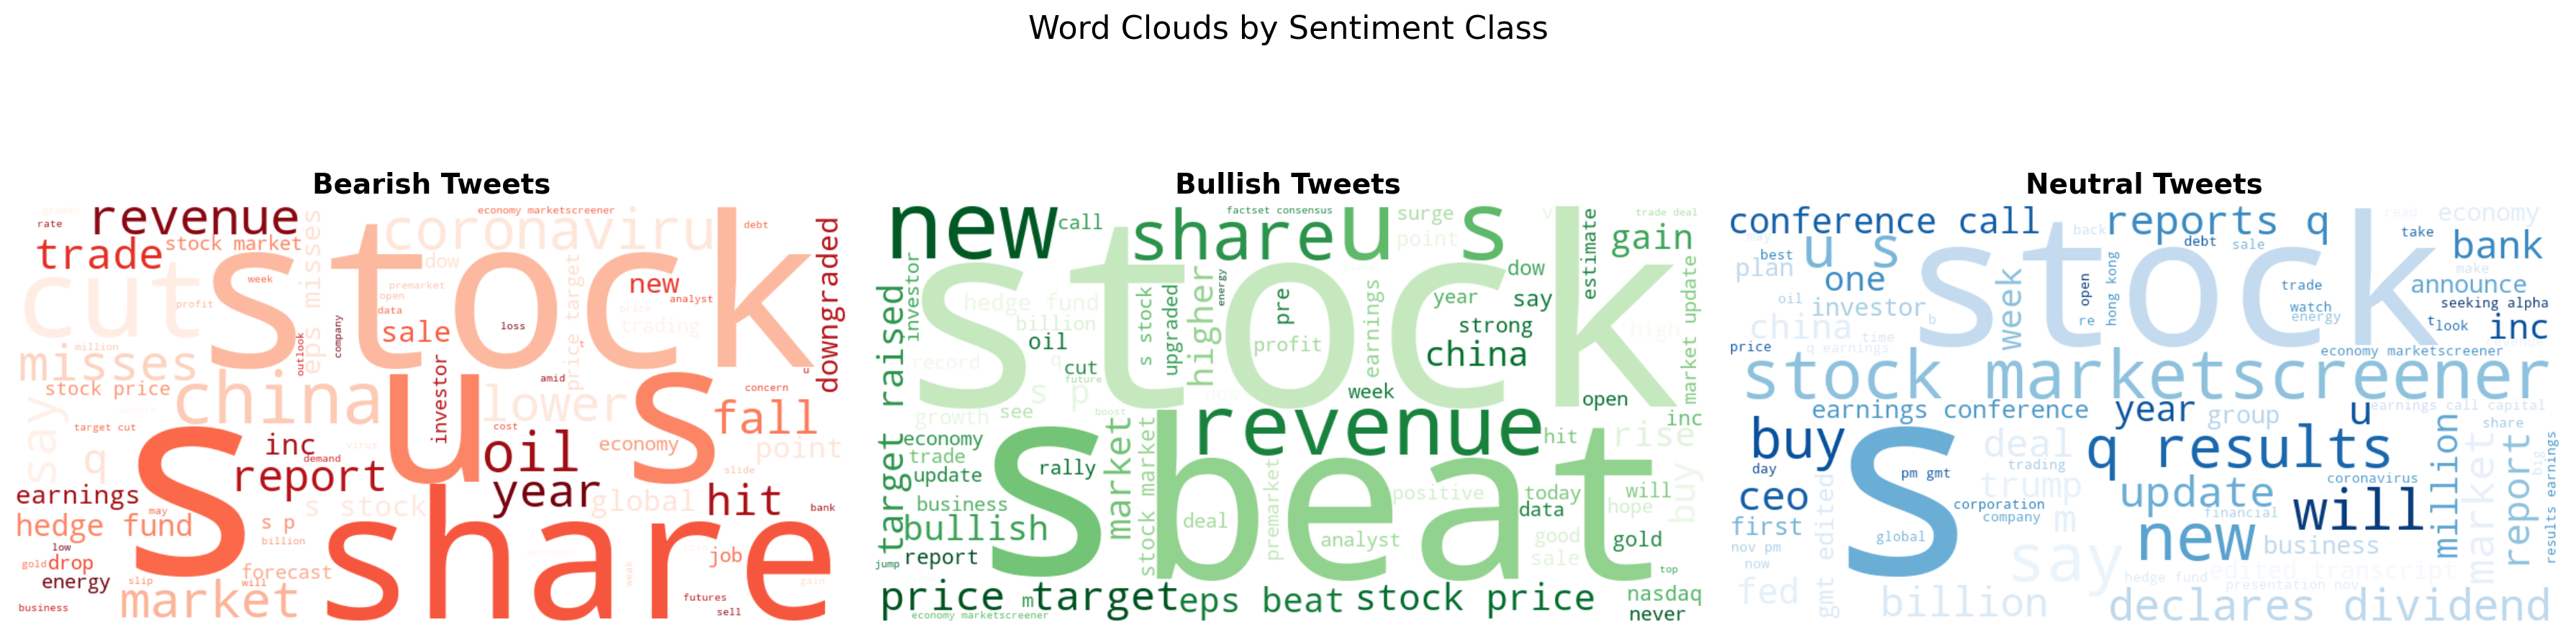

In [11]:
# --- Word clouds per sentiment class --- #
from wordcloud import WordCloud
import re

label_names_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
colormaps = {0: "Reds", 1: "Greens", 2: "Blues"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, sorted(train["label"].unique())):
    subset = train.query("label == @label")
    text = " ".join(subset["text"].str.lower().tolist())
    # Strip URLs, mentions, ticker symbols, and non-alphabetic characters
    text = re.sub(r"http\S+|@\S+|\$[A-Za-z]+|[^a-z\s]", " ", text)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormaps[label],
        max_words=80,
        random_state=73,
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label_names_map[label]} Tweets", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.suptitle("Word Clouds by Sentiment Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The word clouds visualize the most frequent terms for each sentiment class after removing URLs, mentions, and ticker symbols. Bearish tweets are dominated by negative market terms such as *down*, *cut*, and *miss*. Bullish tweets highlight positive signals like *up*, *beat*, and *target*. Neutral tweets center on informational vocabulary including *earnings*, *results*, and *report*. The visual contrast across the three clouds confirms that vocabulary is the primary sentiment signal in this corpus.

An analysis of the most frequent terms reveals clear differences in the vocabulary associated with each sentiment class. Bearish tweets are characterized by negative financial expressions such as down and misses, reflecting adverse market performance, earnings disappointments, or negative analyst assessments. In contrast, Bullish tweets frequently contain terms such as up, beats, price, and target, which are commonly associated with positive market sentiment, earnings outperformance, and upward price expectations. Neutral tweets are dominated by more informational and descriptive terms, including results, earnings, new, and #stock, suggesting a focus on reporting financial events rather than expressing an explicitly positive or negative opinion. Overall, the vocabulary distribution indicates that sentiment classes are primarily distinguished by their semantic content, supporting the use of feature engineering techniques capable of capturing contextual and domain-specific meaning.


## 1.6 Ticker Symbol Features

Measure whether explicit ticker references differ across sentiment classes.


In [12]:
eda_train = eda_train.assign(
    num_tickers=eda_train["text"].str.count(r"\$[A-Za-z]+"),
    has_url=eda_train["text"].str.contains(r"http\S+|www\S+", regex=True),
    has_mention=eda_train["text"].str.contains(r"@\w+", regex=True),
)

eda_train.head()


,text,label,char_length,word_length,num_tickers,has_url,has_mention
0,$BYND - JPMorgan reels in expectations on Beyo...,0,77,10,1,True,False
1,$CCL $RCL - Nomura points to bookings weakness...,0,102,14,2,True,False
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,94,14,1,True,False
3,$ESS: BTIG Research cuts to Neutral https://t....,0,59,7,1,True,False
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,71,10,1,True,False


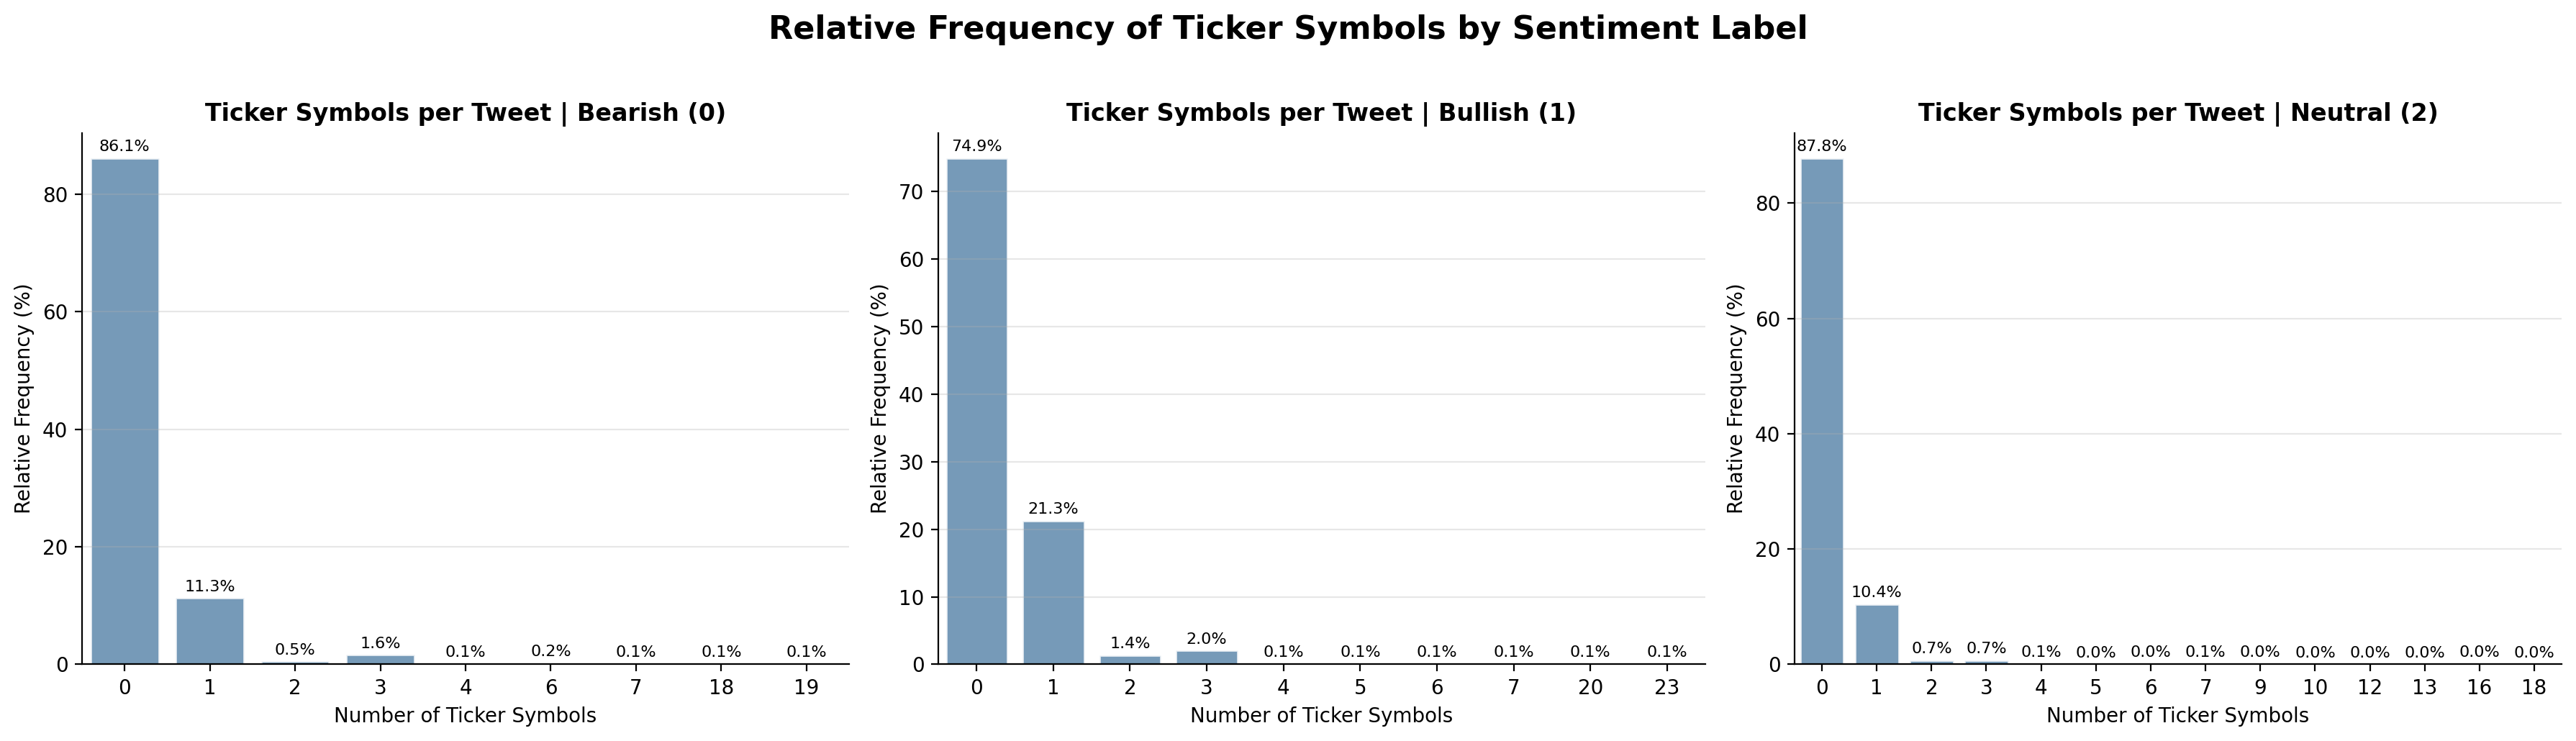

In [13]:
fig, axes = plotting.plot_relative_frequency_by_label(
    eda_train,
    value_col="num_tickers",
    label_col="label",
    title="Relative Frequency of Ticker Symbols by Sentiment Label",
    panel_title="Ticker Symbols per Tweet",
    x_label="Number of Ticker Symbols",
)
fig.savefig(
    FIGURES_DIR / "ticker_symbols_by_sentiment.png", dpi=200, bbox_inches="tight"
)
plt.show()


The relative frequency distributions reveal that the majority of tweets in all sentiment classes do not contain explicit stock ticker references. However, notable differences emerge when the distributions are normalized by class size. Bullish tweets exhibit the highest proportion of tweets containing a single ticker symbol, with approximately 21.3% of observations including exactly one ticker, compared to 11.3% for Bearish tweets and 10.4% for Neutral tweets. This suggests that positive sentiment is more frequently associated with discussions focused on specific companies.

In contrast, Neutral and Bearish tweets are substantially more likely to contain no ticker references, accounting for 87.8% and 86.1% of observations, respectively. This pattern indicates that these classes rely more heavily on general market commentary, financial news, or broader economic discussions rather than company-specific references.

Tweets containing multiple ticker symbols remain relatively uncommon across all sentiment categories, typically representing less than 2% of observations. Such tweets are likely associated with comparative analyses, sector-level commentary, analyst reports, or market summaries involving several firms simultaneously.

Overall, the results suggest that ticker symbols may provide useful information for sentiment classification when present. In particular, the higher prevalence of ticker mentions within Bullish tweets indicates a stronger connection between positive sentiment and company-specific discussions. Nevertheless, because the majority of tweets across all classes contain no ticker references, ticker-related features should be viewed as complementary signals rather than primary predictors of sentiment.


## 1.7 URL and Mention Features

Evaluate URL and mention presence as lightweight structural tweet features.


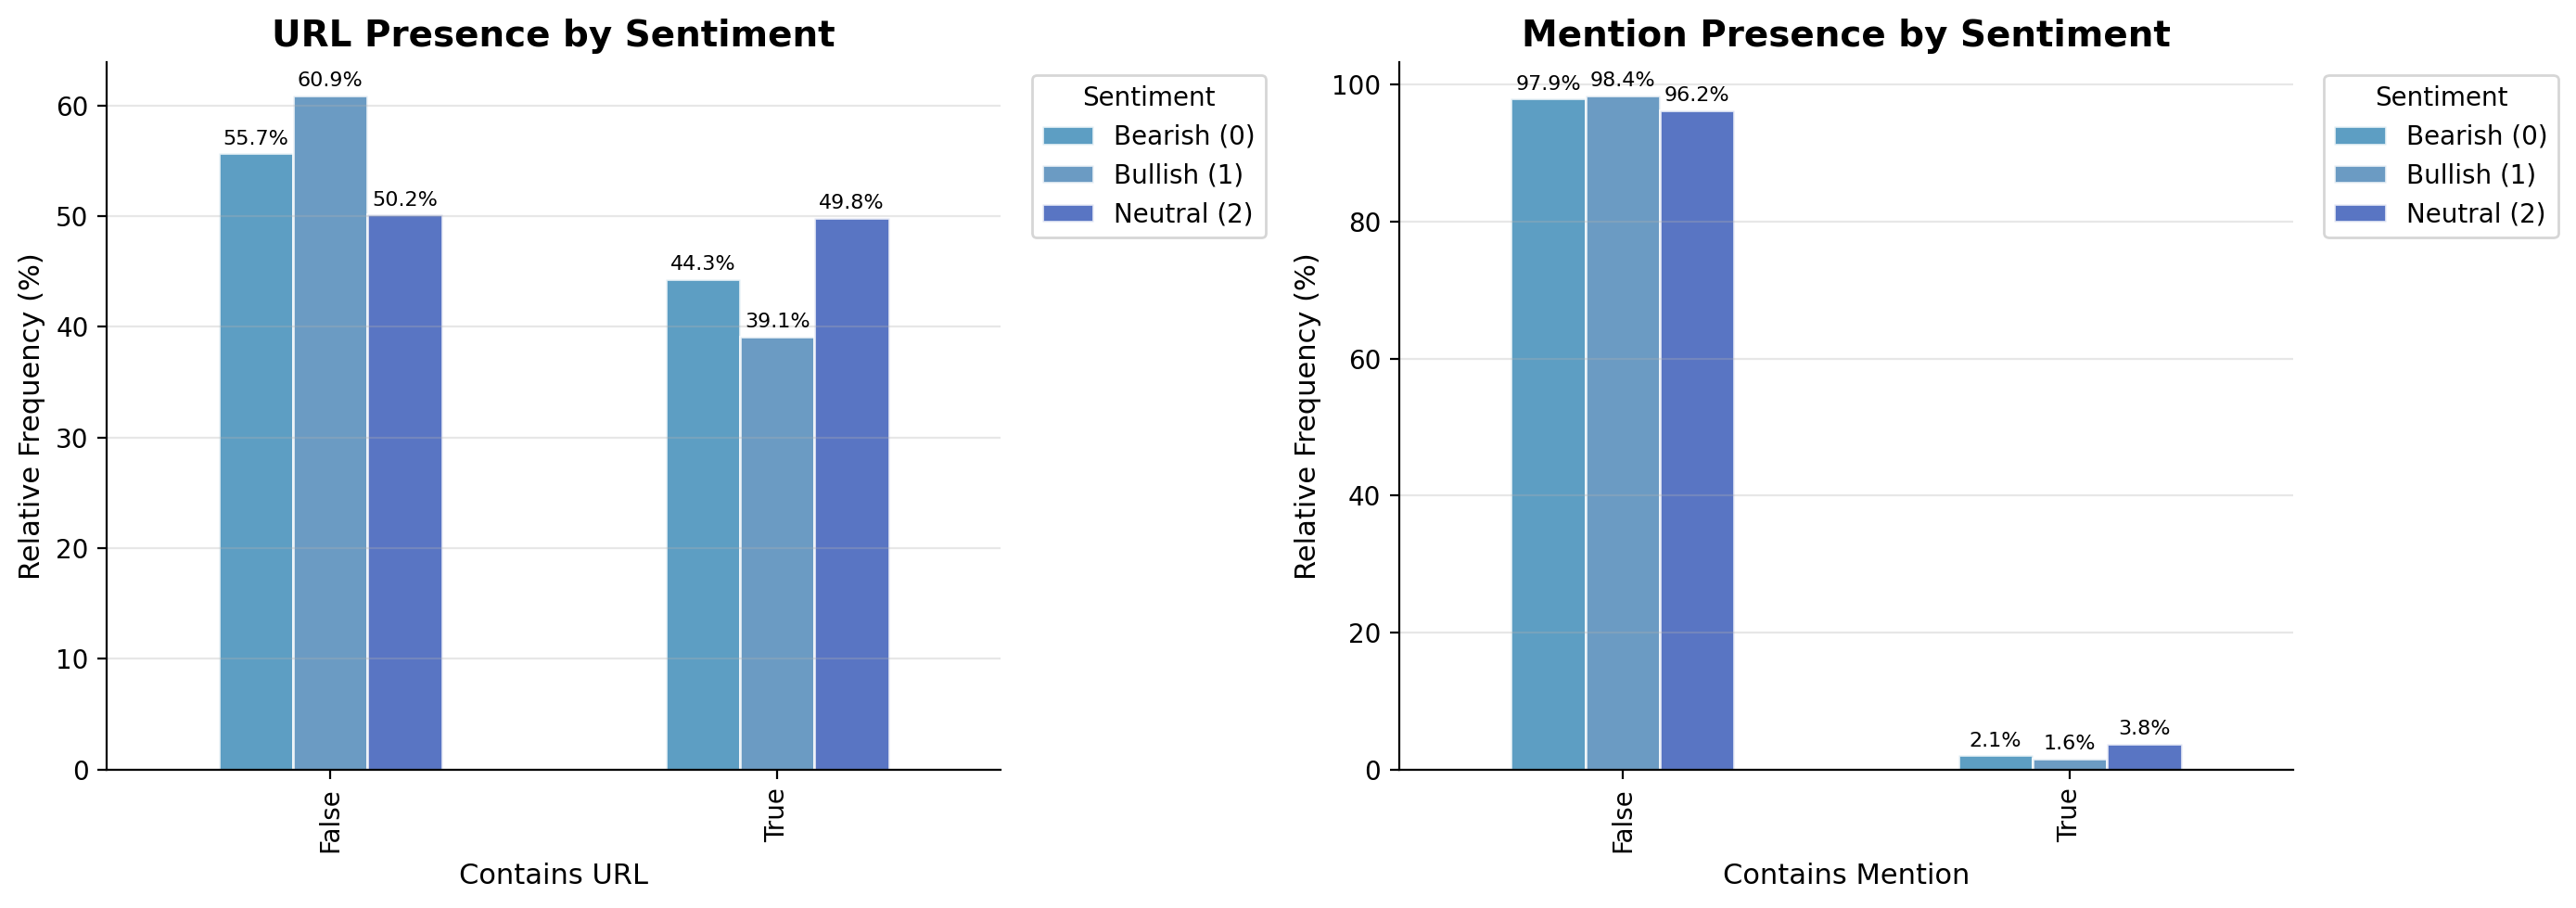

In [14]:
boolean_cols = ["has_url", "has_mention"]
titles = ["URL Presence by Sentiment", "Mention Presence by Sentiment"]
xlabels = ["Contains URL", "Contains Mention"]

fig, axes = plotting.plot_boolean_presence_by_label(
    eda_train,
    boolean_cols,
    label_col="label",
    titles=titles,
    x_labels=xlabels,
)
fig.savefig(
    FIGURES_DIR / "url_mention_presence_by_sentiment.png", dpi=200, bbox_inches="tight"
)
plt.show()


The distributions of URL and user mention presence reveal distinct patterns across the sentiment classes. Approximately half of all tweets contain an external URL, indicating that the corpus includes a substantial amount of news-sharing and information dissemination activity. Bullish tweets exhibit the highest proportion of URLs, with 60.9% of observations containing a link, compared to 55.7% for Bearish tweets and 50.2% for Neutral tweets. This pattern suggests that positive sentiment is more frequently associated with the sharing of external financial news, analyst reports, or company-specific information.

In contrast, user mentions are extremely rare across all sentiment categories. More than 96% of tweets in each class do not contain a mention, with only 1.6–3.8% of observations including a reference to another user. Neutral tweets exhibit the highest proportion of mentions, although the difference relative to the other classes remains small. The scarcity of mentions indicates that the corpus is primarily composed of informational content rather than conversational interactions between users.

From a machine learning perspective, the presence of URLs may provide a useful auxiliary feature, particularly given its varying prevalence across sentiment classes. However, the near absence of user mentions suggests that this characteristic is unlikely to contribute substantially to sentiment discrimination. Overall, these findings reinforce the notion that sentiment classification in this corpus depends predominantly on the semantic content of the tweets rather than on platform-specific structural features.

---


# 2. Train/Validation Split


## 2.1 Stratified Validation Split

Create a reproducible stratified validation split so class proportions remain stable across train and validation data.


In [15]:
# --- Data splitting --- #
X = train["text"]
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=73
)

X_test = test["text"]
submission_ids = test["id"]

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Submission IDs:     {len(submission_ids)}")


Training samples:   7634
Validation samples: 1909
Test samples:       2388
Submission IDs:     2388


---


# 3. Text Preprocessing


## 3.1 Preprocessing Resources and Stopwords

Load NLP resources and define the stopword configuration used by the preprocessing benchmark.


In [16]:
# --- Prepare preprocessing resources and defaults --- #
ensure_nltk_resource("corpora/stopwords", "stopwords")
ensure_nltk_resource("corpora/wordnet", "wordnet")
ensure_nltk_resource("corpora/omw-1.4", "omw-1.4")

english_stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "marketscreener",
    "https",
    "http",
    "www",
    "u",
    "s",
}
stop_words = english_stop_words | custom_stopwords

X_train_clean = X_train.apply(lambda text: preprocess_text(text, stop_words))
X_val_clean = X_val.apply(lambda text: preprocess_text(text, stop_words))
X_test_clean = X_test.apply(lambda text: preprocess_text(text, stop_words))

X_train_clean.head()

1585    instagram willing pay celebrities’ igtv produc...
4687    hyperinflation stagnation, worse? ask latin am...
6663           major indexes red end record-breaking year
6819                                              futures
9494    $sumrx: gapping up/down: smpl +9% earnings/gui...
Name: text, dtype: str

## 3.2 Original Cleaning Pipeline

Apply and inspect the original lowercasing, regex cleaning, and stopword-removal pipeline.


In [17]:
# --- Inspect original versus cleaned text --- #
pd.DataFrame(
    {
        "original": X_train.head(5).values,
        "cleaned": X_train_clean.head(5).values,
    }
)

,original,cleaned
0,Instagram is willing to pay for celebrities’ I...,instagram willing pay celebrities’ igtv produc...
1,"Hyperinflation or Stagnation, Which Is Worse? ...","hyperinflation stagnation, worse? ask latin am..."
2,Major indexes in the red to end record-breakin...,major indexes red end record-breaking year
3,Futures up https://t.co/diz7v5lmVb,futures
4,$SUMRX: Gapping up/down: SMPL +9% after earnin...,$sumrx: gapping up/down: smpl +9% earnings/gui...


In addition to the standard English stopwords provided by NLTK, a small set of domain-specific stopwords was introduced. The objective was to remove terms that primarily reflect the source or structure of the tweets rather than their semantic content or sentiment. The terms `https`, `http`, and `www` were removed because they correspond to URL artifacts generated by links embedded in tweets. Similarly, `marketscreener` was removed because it refers to a news source that appears frequently throughout the corpus and is unlikely to contribute meaningful information for sentiment classification. A conservative approach was maintained when defining the custom stopword list: terms such as _stock_, _shares_, and _new_ were retained because they may still appear in sentiment-bearing expressions such as _stock rises_, _shares plunge_, or _new earnings guidance_.

This strategy minimizes the risk of removing potentially informative financial vocabulary while eliminating source-specific artifacts that are unlikely to improve model performance.


The cleaned text below is the base representation used for downstream variants. Lemmatization and stemming are kept as explicit alternatives so later feature-engineering experiments can compare them against the cleaned baseline.


## 3.3 Lemmatization and Stemming Variants

Build explicit lemmatized and stemmed alternatives from the original cleaned text.


In [18]:
# --- Apply lemmatization to the cleaned text --- #
X_train_lemma = X_train_clean.apply(lemmatize_text)
X_val_lemma = X_val_clean.apply(lemmatize_text)
X_test_lemma = X_test_clean.apply(lemmatize_text)

X_train_lemma.head()


1585    instagram willing pay celebrities’ igtv produc...
4687    hyperinflation stagnation, worse? ask latin am...
6663             major index red end record-breaking year
6819                                               future
9494    $sumrx: gapping up/down: smpl +9% earnings/gui...
Name: text, dtype: str

In [19]:
# --- Apply stemming to the cleaned text --- #
X_train_stem = X_train_clean.apply(stem_text)
X_val_stem = X_val_clean.apply(stem_text)
X_test_stem = X_test_clean.apply(stem_text)

X_train_stem.head()


1585    instagram will pay celebrities’ igtv product c...
4687      hyperinfl stagnation, worse? ask latin america.
6663                major index red end record-break year
6819                                                futur
9494    $sumrx: gap up/down: smpl +9% earnings/guidanc...
Name: text, dtype: str

## 3.4 Preprocessing Quality Assessment

This section evaluates whether the current preprocessing pipeline preserves useful sentiment information before additional feature engineering is introduced. The benchmark below is diagnostic only: every text variant uses the same vectorizer and classifier so differences are attributable to preprocessing rather than model design.


### 3.4.1 Sample Comparison Across Variants


In [20]:
# --- Compare preprocessing variants across labels --- #
preprocessing_compare = pd.DataFrame(
    {
        "label": y_train,
        "original": X_train,
        "cleaned": X_train_clean,
        "lemmatized": X_train_lemma,
        "stemmed": X_train_stem,
    }
)

preprocessing_compare = preprocessing_compare.sort_values("label")
preprocessing_compare.groupby("label", group_keys=False).sample(
    n=3, random_state=73
).reset_index(drop=True)


,label,original,cleaned,lemmatized,stemmed
0,0,Kellogg stock falls after weak guidance,kellogg stock falls weak guidance,kellogg stock fall weak guidance,kellogg stock fall weak guidanc
1,0,Hedge Funds Are Done Buying Waddell & Reed Fin...,hedge funds done buying waddell & reed financi...,hedge fund done buying waddell & reed financia...,"hedg fund done buy waddel & reed financial, in..."
2,0,$MSGN - Imperial downgrades MSG Networks amid ...,$msgn - imperial downgrades msg networks amid ...,$msgn - imperial downgrade msg network amid sp...,$msgn - imperi downgrad msg network amid sport...
3,1,$VIR: Vir Biotechnolog: GlaxoSmithKline (GSK) ...,$vir: vir biotechnolog: glaxosmithkline (gsk) ...,$vir: vir biotechnolog: glaxosmithkline (gsk) ...,$vir: vir biotechnolog: glaxosmithklin (gsk) m...
4,1,Nokia posts surprise quarterly profit rise on ...,nokia posts surprise quarterly profit rise cos...,nokia post surprise quarterly profit rise cost...,nokia post surpris quarterli profit rise cost cut
5,1,$IESC - IES Holdings +8% post Q4 results https...,$iesc - ies holdings +8% post q4 results,$iesc - y holding +8% post q4 result,$iesc - i hold +8% post q4 result
6,2,Here's How P/E Ratios Can Help Us Understand O...,here's p/e ratios help us understand open text...,here's p/e ratio help u understand open text c...,here' p/e ratio help us understand open text c...
7,2,$HPE - Hewlett Packard Enterprise Q4 2019 Earn...,$hpe - hewlett packard enterprise q4 2019 earn...,$hpe - hewlett packard enterprise q4 2019 earn...,$hpe - hewlett packard enterpris q4 2019 earn ...
8,2,$PYX $FARM $TUP - Pyxus International among co...,$pyx $farm $tup - pyxus international among co...,$pyx $farm $tup - pyxus international among co...,$pyx $farm $tup - pyxu intern among consum gai...


### 3.4.2 Text Retention Summary


In [21]:
# --- Quantify text retained by each preprocessing variant --- #
text_variants = {
    "original": X_train,
    "cleaned": X_train_clean,
    "lemmatized": X_train_lemma,
    "stemmed": X_train_stem,
}

retention_rows = []
for variant, texts in text_variants.items():
    texts = texts.fillna("")
    char_lengths = texts.str.len()
    word_lengths = texts.str.split().str.len()

    retention_rows.append(
        {
            "variant": variant,
            "empty_docs": int((word_lengths == 0).sum()),
            "near_empty_docs": int((word_lengths <= 2).sum()),
            "avg_chars": char_lengths.mean(),
            "avg_words": word_lengths.mean(),
        }
    )

retention_summary = pd.DataFrame(retention_rows)
original_avg_chars = retention_summary.loc[
    retention_summary["variant"] == "original", "avg_chars"
].iloc[0]
original_avg_words = retention_summary.loc[
    retention_summary["variant"] == "original", "avg_words"
].iloc[0]

retention_summary["avg_char_reduction_vs_original_pct"] = (
    1 - retention_summary["avg_chars"] / original_avg_chars
) * 100
retention_summary["avg_word_reduction_vs_original_pct"] = (
    1 - retention_summary["avg_words"] / original_avg_words
) * 100

retention_summary.round(2)


,variant,empty_docs,near_empty_docs,avg_chars,avg_words,avg_char_reduction_vs_original_pct,avg_word_reduction_vs_original_pct
0,original,0,33,85.96,12.19,0.00,0.00
1,cleaned,6,73,62.33,8.89,27.49,27.06
2,lemmatized,6,73,61.22,8.89,28.78,27.06
3,stemmed,6,73,56.44,8.89,34.34,27.06


### 3.4.3 Extreme Cleaning Reductions


In [22]:
# --- Inspect examples with the largest cleaning reduction --- #
cleaning_change = pd.DataFrame(
    {
        "label": y_train,
        "original": X_train,
        "cleaned": X_train_clean,
        "original_words": X_train.fillna("").str.split().str.len(),
        "cleaned_words": X_train_clean.fillna("").str.split().str.len(),
    }
)
cleaning_change["removed_words"] = (
    cleaning_change["original_words"] - cleaning_change["cleaned_words"]
)
cleaning_change["word_reduction_pct"] = (
    cleaning_change["removed_words"]
    / cleaning_change["original_words"].replace(0, pd.NA)
    * 100
)

cleaning_change.sort_values(
    ["word_reduction_pct", "removed_words"], ascending=False
).head(10)


,label,original,cleaned,original_words,cleaned_words,removed_words,word_reduction_pct
3950,2,@tictoc @telefenoticias @teleSUR_Chile @Paolad...,,8,0,8,100.0
3949,2,@tictoc @telefenoticias @teleSUR_Chile @Paolad...,,6,0,6,100.0
4683,2,https://t.co/oJxNPEUpWq,,1,0,1,100.0
3948,2,@TicToc,,1,0,1,100.0
4681,2,https://t.co/575AH1YRkF,,1,0,1,100.0
4682,2,https://t.co/9eZPvQhfMq,,1,0,1,100.0
3708,0,And now we sell https://t.co/YAsnS6oIfa,sell,5,1,4,80.0
7052,2,On the hour https://t.co/UjTgLR5wPY,hour,4,1,3,75.0
6992,2,Before the Open https://t.co/1rqW1xDqPE,open,4,1,3,75.0
7053,2,On the hour https://t.co/wrsG5l495t,hour,4,1,3,75.0


### 3.4.4 Stopword and Signal Audit


In [23]:
# --- Check whether stopword removal risks deleting sentiment signals --- #
negation_terms = {"no", "nor", "not", "never", "cannot", "without"}
financial_signal_terms = {
    "$",
    "%",
    "up",
    "down",
    "beat",
    "beats",
    "miss",
    "misses",
    "cut",
    "cuts",
    "raise",
    "raises",
    "fall",
    "falls",
    "gain",
    "gains",
    "loss",
    "losses",
}

signal_audit = pd.DataFrame(
    {
        "check": [
            "negations_removed_as_stopwords",
            "financial_terms_removed_as_stopwords",
            "financial_terms_preserved",
        ],
        "tokens": [
            sorted(negation_terms & stop_words),
            sorted(financial_signal_terms & stop_words),
            sorted(financial_signal_terms - stop_words),
        ],
    }
)

signal_audit


,check,tokens
0,negations_removed_as_stopwords,"[no, nor, not]"
1,financial_terms_removed_as_stopwords,"[down, up]"
2,financial_terms_preserved,"[$, %, beat, beats, cut, cuts, fall, falls, ga..."


## 3.5 Preprocessing Combination Benchmark

This section compares every meaningful combination of the preprocessing strategies used in the notebook. Each row represents one text representation evaluated with the same TF-IDF Logistic Regression diagnostic model, so differences are attributable to preprocessing rather than model design.

The strategy dimensions are:

- `raw_lower`: original tweet text converted to lowercase.
- `regex_clean`: removes URLs, user mentions, and repeated whitespace.
- `stopwords`: removes tokens in the original `stop_words` list.
- `lemmatized`: converts tokens to dictionary-style lemmas.
- `stemmed`: reduces tokens to stems.

Lemmatization and stemming are treated as alternatives rather than stacked transformations.


In [24]:
# --- Build all preprocessing combinations for comparison --- #
import pickle


def apply_preprocessing_strategy(texts, use_regex, use_stopwords, morphology):
    processed = texts.apply(lowercase_text)

    if use_regex:
        processed = processed.apply(regex_clean)
    if use_stopwords:
        processed = processed.apply(lambda text: remove_stopwords(text, stop_words))
    if morphology == "lemmatized":
        processed = processed.apply(lemmatize_text)
    elif morphology == "stemmed":
        processed = processed.apply(stem_text)

    return processed


def preprocessing_variant_name(use_regex, use_stopwords, morphology):
    parts = ["raw_lower"]

    if use_regex:
        parts.append("regex_clean")
    if use_stopwords:
        parts.append("stopwords")
    if morphology != "none":
        parts.append(morphology)

    return "_".join(parts)


X_train_raw_lower = X_train.apply(lowercase_text)
X_val_raw_lower = X_val.apply(lowercase_text)
X_test_raw_lower = X_test.apply(lowercase_text)

_PREPROCESSING_CACHE = PROCESSED_DATA_DIR / "preprocessing_variant_texts.pkl"

if _PREPROCESSING_CACHE.exists():
    print("Loading cached preprocessing variants…")
    with open(_PREPROCESSING_CACHE, "rb") as _f:
        preprocessing_variant_texts = pickle.load(_f)
    preprocessing_combination_rows = [
        {"variant": k, "regex_clean": False, "stopword_removal": False, "morphology": "none"}
        for k in preprocessing_variant_texts
    ]
    print(f"Loaded {len(preprocessing_variant_texts)} cached variants.")
else:
    preprocessing_variant_texts = {
        "original": {
            "train": X_train,
            "val": X_val,
            "test": X_test,
        }
    }
    preprocessing_combination_rows = [
        {
            "variant": "original",
            "regex_clean": False,
            "stopword_removal": False,
            "morphology": "none",
        }
    ]

    for use_regex in (False, True):
        for use_stopwords in (False, True):
            for morphology in ("none", "lemmatized", "stemmed"):
                variant = preprocessing_variant_name(
                    use_regex,
                    use_stopwords,
                    morphology,
                )
                preprocessing_variant_texts[variant] = {
                    "train": apply_preprocessing_strategy(
                        X_train,
                        use_regex,
                        use_stopwords,
                        morphology,
                    ),
                    "val": apply_preprocessing_strategy(
                        X_val,
                        use_regex,
                        use_stopwords,
                        morphology,
                    ),
                    "test": apply_preprocessing_strategy(
                        X_test,
                        use_regex,
                        use_stopwords,
                        morphology,
                    ),
                }
                preprocessing_combination_rows.append(
                    {
                        "variant": variant,
                        "regex_clean": use_regex,
                        "stopword_removal": use_stopwords,
                        "morphology": morphology,
                    }
                )

    _PREPROCESSING_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(_PREPROCESSING_CACHE, "wb") as _f:
        pickle.dump(preprocessing_variant_texts, _f)
    print(f"Computed and cached {len(preprocessing_variant_texts)} preprocessing variants.")

Loading cached preprocessing variants…
Loaded 13 cached variants.


In [25]:
# --- Benchmark each preprocessing combination with the same diagnostic model --- #
_BENCHMARK_CACHE = PROCESSED_DATA_DIR / "preprocessing_benchmark_results.csv"

preprocessing_benchmark_variants = {
    variant: (texts["train"], texts["val"])
    for variant, texts in preprocessing_variant_texts.items()
}

if _BENCHMARK_CACHE.exists():
    print("Loading cached preprocessing benchmark results…")
    preprocessing_combination_results = pd.read_csv(_BENCHMARK_CACHE, index_col=0)
else:
    preprocessing_combination_results = preprocessing.benchmark_variants(
        preprocessing_benchmark_variants,
        y_train,
        y_val,
    ).sort_values("macro_f1", ascending=False)
    _BENCHMARK_CACHE.parent.mkdir(parents=True, exist_ok=True)
    preprocessing_combination_results.to_csv(_BENCHMARK_CACHE)

best_preprocessing_variant = preprocessing_combination_results.index[0]
best_preprocessing_scores = preprocessing_combination_results.loc[
    best_preprocessing_variant
]

X_train_selected_preprocessed = preprocessing_variant_texts[best_preprocessing_variant][
    "train"
]
X_val_selected_preprocessed = preprocessing_variant_texts[best_preprocessing_variant][
    "val"
]
X_test_selected_preprocessed = preprocessing_variant_texts[best_preprocessing_variant][
    "test"
]

print(f"Evaluated preprocessing variants: {len(preprocessing_combination_results)}")
print(f"Best preprocessing variant: {best_preprocessing_variant}")
print(f"Best Macro F1: {best_preprocessing_scores['macro_f1']:.4f}")

display(preprocessing_combination_results.round(4))

Loading cached preprocessing benchmark results…
Evaluated preprocessing variants: 13
Best preprocessing variant: raw_lower_regex_clean_stemmed
Best Macro F1: 0.7045


,macro_f1,weighted_f1,accuracy
variant,,,
raw_lower_regex_clean_stemmed,0.7045,0.7895,0.8051
raw_lower_stemmed,0.7019,0.7881,0.8041
raw_lower_lemmatized,0.6888,0.7782,0.7962
raw_lower_regex_clean_lemmatized,0.6865,0.7768,0.7952
raw_lower_regex_clean,0.6850,0.7780,0.7978
original,0.6833,0.7768,0.7968
raw_lower,0.6833,0.7768,0.7968
raw_lower_regex_clean_stopwords_stemmed,0.6721,0.7658,0.7852
raw_lower_stopwords_stemmed,0.6717,0.7669,0.7868


The strongest preprocessing strategy is selected by validation Macro F1 because the sentiment labels are imbalanced. Weighted F1 and Accuracy are retained as secondary diagnostics, but the final choice should prioritize balanced performance across Bearish, Bullish, and Neutral classes.


## Section 3 Conclusion

The full combination benchmark selects `raw_lower_regex_clean_stemmed` as the strongest preprocessing representation. This variant lowercases the tweets, removes URL and mention noise with regex cleaning, and applies stemming, while avoiding stopword removal.

The result is stronger than the previous lowercase-only baseline: Macro F1 improves from `0.6833` for `raw_lower` to `0.7045` for `raw_lower_regex_clean_stemmed`. The same row also reaches Weighted F1 `0.7895` and Accuracy `0.8051`.

The main practical conclusion is that regex cleaning and stemming help in this diagnostic setup, while stopword removal remains harmful across the tested combinations.

---


# 4. Feature Engineering

This section implements the required feature engineering families: plain Bag of Words, TF-IDF, Word2Vec embeddings, and FinBERT transformer encoder embeddings. The preprocessing combination benchmark selected `raw_lower_regex_clean_stemmed` as the strongest diagnostic text representation, so BoW, TF-IDF, and Word2Vec use that selected preprocessing output. FinBERT uses the original tweet text because transformer encoders are pretrained with their own tokenizer and usually benefit from preserved natural-language context.


## 4.1 Feature Inputs and Benchmark Helper

All feature families are compared with the same diagnostic classifier so differences mainly reflect the representation. Sparse BoW and TF-IDF features go directly into Logistic Regression. Dense Word2Vec and FinBERT embeddings are standardized before Logistic Regression.


In [26]:
# --- Define feature inputs and a shared benchmark helper --- #
FEATURE_TEXT_VARIANT = best_preprocessing_variant

X_train_feature_preprocessed = X_train_selected_preprocessed
X_val_feature_preprocessed = X_val_selected_preprocessed
X_test_feature_preprocessed = X_test_selected_preprocessed

X_train_feature_original = X_train
X_val_feature_original = X_val
X_test_feature_original = X_test

feature_benchmark_rows = []
feature_shape_rows = []
feature_classification_reports = {}

## 4.2 Bag of Words and TF-IDF

`CountVectorizer` is the explicit Bag of Words baseline. `TfidfVectorizer` is the weighted BoW variation that downweights common terms and upweights more discriminative terms. Both sparse feature families use the selected `raw_lower_regex_clean_stemmed` preprocessing output.


In [27]:
# --- Build sparse BoW and TF-IDF feature matrices --- #
bow_vectorizer = CountVectorizer(min_df=2)
X_train_bow = bow_vectorizer.fit_transform(X_train_feature_preprocessed)
X_val_bow = bow_vectorizer.transform(X_val_feature_preprocessed)
X_test_bow = bow_vectorizer.transform(X_test_feature_preprocessed)

benchmark_row, shape_row, report = features.benchmark_feature_matrix(
    f"bow_count_{FEATURE_TEXT_VARIANT}",
    "BoW",
    X_train_bow,
    X_val_bow,
    y_train,
    y_val,
)
feature_benchmark_rows.append(benchmark_row)
feature_shape_rows.append(shape_row)
feature_classification_reports[benchmark_row["variant"]] = report

tfidf_vectorizer = TfidfVectorizer(min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_feature_preprocessed)
X_val_tfidf = tfidf_vectorizer.transform(X_val_feature_preprocessed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_feature_preprocessed)

benchmark_row, shape_row, report = features.benchmark_feature_matrix(
    f"tfidf_{FEATURE_TEXT_VARIANT}",
    "TF-IDF",
    X_train_tfidf,
    X_val_tfidf,
    y_train,
    y_val,
)
feature_benchmark_rows.append(benchmark_row)
feature_shape_rows.append(shape_row)
feature_classification_reports[benchmark_row["variant"]] = report

pd.DataFrame(feature_shape_rows)

,variant,feature_family,train_shape,val_shape,feature_dim
0,bow_count_raw_lower_regex_clean_stemmed,BoW,"(7634, 5482)","(1909, 5482)",5482
1,tfidf_raw_lower_regex_clean_stemmed,TF-IDF,"(7634, 5482)","(1909, 5482)",5482


## 4.3 Word2Vec Embeddings

The Word2Vec variation trains a skip-gram model on the selected preprocessed training tweets, then represents each tweet by averaging the vectors for its known tokens. This gives one dense vector per tweet while keeping the experiment reproducible within the project dataset.


In [28]:
# --- Train Word2Vec and average token vectors per tweet --- #
word2vec_train_tokens = features.tokenize_for_word2vec(X_train_feature_preprocessed)
word2vec_val_tokens = features.tokenize_for_word2vec(X_val_feature_preprocessed)
word2vec_test_tokens = features.tokenize_for_word2vec(X_test_feature_preprocessed)

_WORD2VEC_MODEL_PATH = FEATURE_CACHE_DIR / "word2vec_skipgram_100d.model"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if _WORD2VEC_MODEL_PATH.exists():
    print("Loading cached Word2Vec model…")
    word2vec_model = GensimWord2Vec.load(str(_WORD2VEC_MODEL_PATH))
else:
    word2vec_model = features.train_word2vec_model(
        word2vec_train_tokens,
        vector_size=100,
        window=5,
        min_count=2,
        sg=1,
        seed=73,
        epochs=20,
    )
    word2vec_model.save(str(_WORD2VEC_MODEL_PATH))
    print("Word2Vec model trained and cached.")

word2vec_cache_prefix = f"word2vec_skipgram_100d_{FEATURE_TEXT_VARIANT}"

X_train_word2vec = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / f"{word2vec_cache_prefix}_train.npy",
    lambda: features.average_word2vec_embeddings(word2vec_train_tokens, word2vec_model),
)
X_val_word2vec = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / f"{word2vec_cache_prefix}_val.npy",
    lambda: features.average_word2vec_embeddings(word2vec_val_tokens, word2vec_model),
)
X_test_word2vec = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / f"{word2vec_cache_prefix}_test.npy",
    lambda: features.average_word2vec_embeddings(word2vec_test_tokens, word2vec_model),
)

benchmark_row, shape_row, report = features.benchmark_feature_matrix(
    f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}",
    "Word2Vec",
    X_train_word2vec,
    X_val_word2vec,
    y_train,
    y_val,
    scale_dense=True,
)
feature_benchmark_rows.append(benchmark_row)
feature_shape_rows.append(shape_row)
feature_classification_reports[benchmark_row["variant"]] = report

pd.DataFrame(feature_shape_rows)

Loading cached Word2Vec model…


,variant,feature_family,train_shape,val_shape,feature_dim
0,bow_count_raw_lower_regex_clean_stemmed,BoW,"(7634, 5482)","(1909, 5482)",5482
1,tfidf_raw_lower_regex_clean_stemmed,TF-IDF,"(7634, 5482)","(1909, 5482)",5482
2,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Word2Vec,"(7634, 100)","(1909, 100)",100


## 4.4 FinBERT Transformer Encoder Embeddings

FinBERT is used as the Transformer Encoder representation. The notebook loads `ProsusAI/finbert`, extracts last-hidden-state token embeddings, and mean-pools them with the attention mask to produce one contextual dense vector per tweet. FinBERT intentionally uses the original tweet text because its pretrained tokenizer expects natural text rather than stemmed tokens. The embeddings are cached locally under `data/processed/features/` because this step is the slowest part of feature engineering.


In [29]:
# --- Encode tweets with FinBERT mean-pooled transformer embeddings --- #
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_BATCH_SIZE = 16
FINBERT_MAX_LENGTH = 128
finbert_device = features.get_torch_device()

print(f"FinBERT embedding device: {finbert_device}")

X_train_finbert = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "finbert_prosusai_mean_pool_train.npy",
    lambda: features.encode_transformer_mean_pool(
        X_train_feature_original,
        FINBERT_MODEL_NAME,
        batch_size=FINBERT_BATCH_SIZE,
        max_length=FINBERT_MAX_LENGTH,
        device=finbert_device,
    ),
)
X_val_finbert = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "finbert_prosusai_mean_pool_val.npy",
    lambda: features.encode_transformer_mean_pool(
        X_val_feature_original,
        FINBERT_MODEL_NAME,
        batch_size=FINBERT_BATCH_SIZE,
        max_length=FINBERT_MAX_LENGTH,
        device=finbert_device,
    ),
)
X_test_finbert = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "finbert_prosusai_mean_pool_test.npy",
    lambda: features.encode_transformer_mean_pool(
        X_test_feature_original,
        FINBERT_MODEL_NAME,
        batch_size=FINBERT_BATCH_SIZE,
        max_length=FINBERT_MAX_LENGTH,
        device=finbert_device,
    ),
)

benchmark_row, shape_row, report = features.benchmark_feature_matrix(
    "finbert_mean_pool_original",
    "Transformer Encoder",
    X_train_finbert,
    X_val_finbert,
    y_train,
    y_val,
    scale_dense=True,
)
feature_benchmark_rows.append(benchmark_row)
feature_shape_rows.append(shape_row)
feature_classification_reports[benchmark_row["variant"]] = report

pd.DataFrame(feature_shape_rows)

FinBERT embedding device: mps


,variant,feature_family,train_shape,val_shape,feature_dim
0,bow_count_raw_lower_regex_clean_stemmed,BoW,"(7634, 5482)","(1909, 5482)",5482
1,tfidf_raw_lower_regex_clean_stemmed,TF-IDF,"(7634, 5482)","(1909, 5482)",5482
2,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Word2Vec,"(7634, 100)","(1909, 100)",100
3,finbert_mean_pool_original,Transformer Encoder,"(7634, 768)","(1909, 768)",768


## 4.5 Feature Engineering Results

The table below compares all feature representations with macro F1 as the primary metric. Macro F1 is preferred because the dataset is class-imbalanced and Bearish/Bullish recall matters more than raw accuracy alone.


In [30]:
# --- Compare feature representation quality --- #
feature_shape_summary = pd.DataFrame(feature_shape_rows)
feature_benchmark_results = pd.DataFrame(feature_benchmark_rows).sort_values(
    "macro_f1", ascending=False
)

display(feature_shape_summary)
display(feature_benchmark_results.round(4))

# --- Best variant --- #
best_feature_variant = feature_benchmark_results.iloc[0]["variant"]
print(f"Best feature representation by macro F1: {best_feature_variant}")


,variant,feature_family,train_shape,val_shape,feature_dim
0,bow_count_raw_lower_regex_clean_stemmed,BoW,"(7634, 5482)","(1909, 5482)",5482
1,tfidf_raw_lower_regex_clean_stemmed,TF-IDF,"(7634, 5482)","(1909, 5482)",5482
2,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Word2Vec,"(7634, 100)","(1909, 100)",100
3,finbert_mean_pool_original,Transformer Encoder,"(7634, 768)","(1909, 768)",768


,variant,feature_family,macro_f1,weighted_f1,accuracy
3,finbert_mean_pool_original,Transformer Encoder,0.7412,0.8063,0.8078
0,bow_count_raw_lower_regex_clean_stemmed,BoW,0.7243,0.7996,0.8051
1,tfidf_raw_lower_regex_clean_stemmed,TF-IDF,0.7045,0.7895,0.8051
2,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Word2Vec,0.6088,0.7266,0.7465


Best feature representation by macro F1: finbert_mean_pool_original


In [31]:
# --- Review per-class metrics for the strongest feature representation --- #
pd.DataFrame(feature_classification_reports[best_feature_variant]).transpose().round(4)


,precision,recall,f1-score,support
0,0.6540,0.5972,0.6243,288.0000
1,0.7205,0.7299,0.7252,385.0000
2,0.8670,0.8811,0.8740,1236.0000
accuracy,0.8078,0.8078,0.8078,0.8078
macro avg,0.7472,0.7361,0.7412,1909.0000
weighted avg,0.8053,0.8078,0.8063,1909.0000


## Feature engineering conclusion

`finbert_mean_pool_original` is the strongest feature representation in this benchmark, with macro F1 `0.7412`,
weighted F1 `0.8063`, and accuracy `0.8078`. It performs best on the primary comparison metric and slightly
outperforms the strongest sparse baseline, `bow_count_raw_lower_regex_clean_stemmed` (`0.7243` macro F1).

This result makes `finbert_mean_pool_original` the preferred input representation for the classification-model section, where it will be compared again alongside the BoW, TF-IDF, and Word2Vec representations.


# 5. Classification Models

This section evaluates the classification performance of different feature representations introduced in Section 4. Both traditional machine learning classifiers and Transformer-based encoder models are assessed using a common validation split and a consistent set of evaluation metrics. This comparison aims to determine how the choice of text representation influences predictive performance and to identify the most effective approach for the financial tweet classification task.


## 5.1 Model Benchmark Design

The benchmark uses three representation families and pairs each with two classifier variations:

| Feature engineering                                         | Classifier variation 1                        | Classifier variation 2        | Why                                                                                    |
| ----------------------------------------------------------- | --------------------------------------------- | ----------------------------- | -------------------------------------------------------------------------------------- |
| TF-IDF on `raw_lower_regex_clean_stemmed`                   | Logistic Regression                           | Linear SVM                    | Strong sparse-text baselines with linear decision boundaries.                          |
| Word2Vec mean embeddings on `raw_lower_regex_clean_stemmed` | Logistic Regression                           | MLP                           | Tests whether dense static embeddings help linear and nonlinear classifiers.           |
| FinBERT Transformer Encoder                                 | Logistic Regression on mean-pooled embeddings | Fine-tuned FinBERT classifier | Compares transformer feature extraction against end-to-end transformer classification. |

Each classifier family has two variations so the comparison tests both method choice and configuration sensitivity.


In [32]:
# --- Define classification benchmark inputs and model specifications --- #
classification_feature_sets = {
    f"tfidf_{FEATURE_TEXT_VARIANT}": (X_train_tfidf, X_val_tfidf),
    f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}": (
        X_train_word2vec,
        X_val_word2vec,
    ),
    "finbert_mean_pool_original": (X_train_finbert, X_val_finbert),
}

classification_model_specs = [
    models.SklearnModelSpec(
        variant="tfidf_logreg_baseline",
        representation=f"tfidf_{FEATURE_TEXT_VARIANT}",
        classifier_family="Logistic Regression",
        model=LogisticRegression(max_iter=1000, random_state=73),
    ),
    models.SklearnModelSpec(
        variant="tfidf_logreg_balanced",
        representation=f"tfidf_{FEATURE_TEXT_VARIANT}",
        classifier_family="Logistic Regression",
        model=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=73,
        ),
    ),
    models.SklearnModelSpec(
        variant="tfidf_linear_svm_baseline",
        representation=f"tfidf_{FEATURE_TEXT_VARIANT}",
        classifier_family="Linear SVM",
        model=LinearSVC(C=1.0, random_state=73),
    ),
    models.SklearnModelSpec(
        variant="tfidf_linear_svm_balanced",
        representation=f"tfidf_{FEATURE_TEXT_VARIANT}",
        classifier_family="Linear SVM",
        model=LinearSVC(C=1.0, class_weight="balanced", random_state=73),
    ),
    models.SklearnModelSpec(
        variant="word2vec_logreg_baseline",
        representation=f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}",
        classifier_family="Logistic Regression",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(max_iter=1000, random_state=73)),
            ]
        ),
    ),
    models.SklearnModelSpec(
        variant="word2vec_logreg_balanced",
        representation=f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}",
        classifier_family="Logistic Regression",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=1000,
                        class_weight="balanced",
                        random_state=73,
                    ),
                ),
            ]
        ),
    ),
    models.SklearnModelSpec(
        variant="word2vec_mlp_shallow",
        representation=f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}",
        classifier_family="MLP",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    MLPClassifier(
                        hidden_layer_sizes=(100,),
                        max_iter=300,
                        early_stopping=True,
                        random_state=73,
                    ),
                ),
            ]
        ),
    ),
    models.SklearnModelSpec(
        variant="word2vec_mlp_deep",
        representation=f"word2vec_skipgram_mean_{FEATURE_TEXT_VARIANT}",
        classifier_family="MLP",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    MLPClassifier(
                        hidden_layer_sizes=(128, 64),
                        max_iter=300,
                        early_stopping=True,
                        random_state=73,
                    ),
                ),
            ]
        ),
    ),
    models.SklearnModelSpec(
        variant="finbert_embedding_logreg_baseline",
        representation="finbert_mean_pool_original",
        classifier_family="FinBERT Embeddings + Logistic Regression",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(max_iter=1000, random_state=73)),
            ]
        ),
    ),
    models.SklearnModelSpec(
        variant="finbert_embedding_logreg_balanced",
        representation="finbert_mean_pool_original",
        classifier_family="FinBERT Embeddings + Logistic Regression",
        model=Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=1000,
                        class_weight="balanced",
                        random_state=73,
                    ),
                ),
            ]
        ),
    ),
]

classification_model_plan = pd.DataFrame(
    [
        {
            "variant": spec.variant,
            "representation": spec.representation,
            "classifier_family": spec.classifier_family,
        }
        for spec in classification_model_specs
    ]
)
classification_model_plan


,variant,representation,classifier_family
0,tfidf_logreg_baseline,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression
1,tfidf_logreg_balanced,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression
2,tfidf_linear_svm_baseline,tfidf_raw_lower_regex_clean_stemmed,Linear SVM
3,tfidf_linear_svm_balanced,tfidf_raw_lower_regex_clean_stemmed,Linear SVM
4,word2vec_logreg_baseline,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Logistic Regression
5,word2vec_logreg_balanced,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Logistic Regression
6,word2vec_mlp_shallow,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP
7,word2vec_mlp_deep,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP
8,finbert_embedding_logreg_baseline,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression
9,finbert_embedding_logreg_balanced,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression


**Classification Variants**

The classification experiments evaluate multiple combinations of text representations and classifiers for the financial sentiment classification task. The objective is to compare sparse lexical representations (TF-IDF), dense distributional representations (Word2Vec), and contextual Transformer-based representations (FinBERT) under a common evaluation framework.

The evaluated variants are defined as follows:

- tfidf_logreg_baseline: TF-IDF features with a standard Logistic Regression classifier.
- tfidf_logreg_balanced: TF-IDF features with Logistic Regression using class_weight="balanced" to compensate for class imbalance.
- tfidf_linear_svm_baseline: TF-IDF features with a standard Linear SVM classifier.
- tfidf_linear_svm_balanced: TF-IDF features with a Linear SVM classifier using class_weight="balanced".

- word2vec_logreg_baseline: Mean-pooled Word2Vec embeddings followed by feature scaling and a standard Logistic Regression classifier.
- word2vec_logreg_balanced: Mean-pooled Word2Vec embeddings followed by feature scaling and Logistic Regression using class_weight="balanced".
- word2vec_mlp_shallow: Mean-pooled Word2Vec embeddings followed by feature scaling and a shallow multilayer perceptron (MLP) with a single hidden layer of 100 units.
- word2vec_mlp_deep: Mean-pooled Word2Vec embeddings followed by feature scaling and a deeper MLP with hidden layers of 128 and 64 units.

- finbert_embedding_logreg_baseline: Mean-pooled FinBERT embeddings extracted from the original tweet text and classified using standard Logistic Regression.
- finbert_embedding_logreg_balanced: Mean-pooled FinBERT embeddings extracted from the original tweet text and classified using Logistic Regression with class_weight="balanced".

The terms baseline and balanced distinguish whether class weighting is applied during training. Baseline models use the classifier's default settings, whereas balanced models automatically assign greater weight to minority classes in an attempt to mitigate class imbalance.

The feature representations used throughout this section are:

- tfidf_raw_lower_regex_clean: Text converted to lowercase and cleaned using regex-based preprocessing before TF-IDF vectorization.
- word2vec_skipgram_mean_raw_lower_regex_clean: The same preprocessed text represented using Word2Vec skip-gram embeddings and aggregated through mean pooling.
- finbert_mean_pool_original: The original tweet text encoded using FinBERT, with token embeddings aggregated through mean pooling to obtain a fixed-length document representation.


## 5.2 Traditional ML Classifiers

The traditional benchmark compares linear classifiers on TF-IDF with linear and neural classifiers on Word2Vec mean-pooled embeddings. Macro F1 remains the primary metric because the labels are imbalanced.


In [33]:
# --- Benchmark traditional ML classifiers --- #
classification_results, classification_reports = models.benchmark_sklearn_specs(
    classification_model_specs,
    classification_feature_sets,
    y_train,
    y_val,
)

traditional_results = classification_results[
    ~classification_results["classifier_family"].str.contains("FinBERT")
].sort_values("macro_f1", ascending=False)

traditional_results.round(4)


,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
1,tfidf_logreg_balanced,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression,0.7409,0.8045,0.7994
3,tfidf_linear_svm_balanced,tfidf_raw_lower_regex_clean_stemmed,Linear SVM,0.7339,0.8039,0.8030
2,tfidf_linear_svm_baseline,tfidf_raw_lower_regex_clean_stemmed,Linear SVM,0.7337,0.8037,0.8088
0,tfidf_logreg_baseline,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression,0.7045,0.7895,0.8051
7,word2vec_mlp_deep,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP,0.6895,0.7769,0.7816
6,word2vec_mlp_shallow,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP,0.6804,0.7753,0.7863
4,word2vec_logreg_baseline,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Logistic Regression,0.6088,0.7266,0.7465
5,word2vec_logreg_balanced,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Logistic Regression,0.5994,0.6826,0.6616


## 5.3 Transformer Encoder Classifiers

Transformer Encoder experiments include frozen FinBERT embeddings with Logistic Regression and two sequence-classifier fine-tuning modes: classifier-head-only and full fine-tuning. The fine-tuned variants use original tweets instead of stemmed text so the pretrained tokenizer sees natural language.


In [34]:
# --- Benchmark FinBERT embedding classifiers --- #
transformer_embedding_results = classification_results[
    classification_results["classifier_family"].str.contains("FinBERT")
].sort_values("macro_f1", ascending=False)

transformer_embedding_results.round(4)


,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
8,finbert_embedding_logreg_baseline,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression,0.7412,0.8063,0.8078
9,finbert_embedding_logreg_balanced,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression,0.7250,0.7812,0.7737


In [35]:
# --- Fine-tune FinBERT sequence classifiers --- #
FINBERT_FINE_TUNE_EPOCHS = 2
FINBERT_FINE_TUNE_BATCH_SIZE = 16
FINBERT_FINE_TUNE_MAX_LENGTH = 128
FINBERT_FINE_TUNE_LR = 2e-5

_FINBERT_RESULTS_CACHE = FEATURE_CACHE_DIR / "finbert_finetune_results.pkl"

finbert_finetune_rows = []
finbert_finetune_reports = {}

if _FINBERT_RESULTS_CACHE.exists():
    print("Loading cached FinBERT fine-tuning results…")
    with open(_FINBERT_RESULTS_CACHE, "rb") as _f:
        _finbert_cache = pickle.load(_f)
    finbert_finetune_rows = _finbert_cache["rows"]
    finbert_finetune_reports = _finbert_cache["reports"]
    print(f"Loaded results for: {[r['variant'] for r in finbert_finetune_rows]}")
else:
    for variant, freeze_encoder in [
        ("finbert_classifier_head_only", True),
        ("finbert_full_finetune", False),
    ]:
        row, report = models.train_transformer_classifier(
            variant=variant,
            model_name=FINBERT_MODEL_NAME,
            train_texts=X_train_feature_original,
            val_texts=X_val_feature_original,
            y_train=y_train,
            y_val=y_val,
            num_labels=len(sorted(y_train.unique())),
            device=finbert_device,
            max_length=FINBERT_FINE_TUNE_MAX_LENGTH,
            batch_size=FINBERT_FINE_TUNE_BATCH_SIZE,
            epochs=FINBERT_FINE_TUNE_EPOCHS,
            learning_rate=FINBERT_FINE_TUNE_LR,
            freeze_encoder=freeze_encoder,
            seed=73,
        )
        finbert_finetune_rows.append(row)
        finbert_finetune_reports[variant] = report

    _FINBERT_RESULTS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(_FINBERT_RESULTS_CACHE, "wb") as _f:
        pickle.dump({"rows": finbert_finetune_rows, "reports": finbert_finetune_reports}, _f)
    print("FinBERT fine-tuning complete and results cached.")

finbert_finetune_results = pd.DataFrame(finbert_finetune_rows).sort_values(
    "macro_f1",
    ascending=False,
)
classification_reports.update(finbert_finetune_reports)

finbert_finetune_results.round(4)

Loading cached FinBERT fine-tuning results…
Loaded results for: ['finbert_classifier_head_only', 'finbert_full_finetune']


,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
1,finbert_full_finetune,finbert_sequence,Fine-tuned FinBERT,0.8221,0.8645,0.8617
0,finbert_classifier_head_only,finbert_sequence,Fine-tuned FinBERT,0.6813,0.7452,0.7433


# 6. Evaluation and Analysis

This section uses the model outputs produced in Section 5 to perform the final evaluation. No models are retrained here; the purpose is to compare the completed runs with the required metrics and explain what those metrics mean for financial tweet sentiment classification.


## 6.1 Final Model Comparison

The table below combines the traditional ML, FinBERT embedding, and fine-tuned FinBERT runs. Macro F1 remains the primary ranking metric because the dataset is imbalanced: Neutral is the majority class, while Bearish and Bullish are smaller but important sentiment categories.


In [36]:
# --- Combine and rank all classification models for final evaluation --- #
all_classification_results = pd.concat(
    [classification_results, finbert_finetune_results],
    ignore_index=True,
).sort_values("macro_f1", ascending=False)

all_classification_results = all_classification_results.assign(
    rank=range(1, len(all_classification_results) + 1)
)[
    [
        "rank",
        "variant",
        "representation",
        "classifier_family",
        "macro_f1",
        "weighted_f1",
        "accuracy",
    ]
]

best_classification_model = all_classification_results.iloc[0]["variant"]
best_model_row = all_classification_results.iloc[0]

model_family_coverage = (
    all_classification_results.groupby(["representation", "classifier_family"])
    .size()
    .reset_index(name="variations")
    .sort_values(["representation", "classifier_family"])
)

display(model_family_coverage)
display(all_classification_results.round(4))
print(f"Best classification model by macro F1: {best_classification_model}")


,representation,classifier_family,variations
0,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression,2
1,finbert_sequence,Fine-tuned FinBERT,2
2,tfidf_raw_lower_regex_clean_stemmed,Linear SVM,2
3,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression,2
4,word2vec_skipgram_mean_raw_lower_regex_clean_s...,Logistic Regression,2
5,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP,2


,rank,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
10,1,finbert_full_finetune,finbert_sequence,Fine-tuned FinBERT,0.8221,0.8645,0.8617
8,2,finbert_embedding_logreg_baseline,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression,0.7412,0.8063,0.8078
1,3,tfidf_logreg_balanced,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression,0.7409,0.8045,0.7994
3,4,tfidf_linear_svm_balanced,tfidf_raw_lower_regex_clean_stemmed,Linear SVM,0.7339,0.8039,0.8030
2,5,tfidf_linear_svm_baseline,tfidf_raw_lower_regex_clean_stemmed,Linear SVM,0.7337,0.8037,0.8088
9,6,finbert_embedding_logreg_balanced,finbert_mean_pool_original,FinBERT Embeddings + Logistic Regression,0.7250,0.7812,0.7737
0,7,tfidf_logreg_baseline,tfidf_raw_lower_regex_clean_stemmed,Logistic Regression,0.7045,0.7895,0.8051
7,8,word2vec_mlp_deep,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP,0.6895,0.7769,0.7816
11,9,finbert_classifier_head_only,finbert_sequence,Fine-tuned FinBERT,0.6813,0.7452,0.7433
6,10,word2vec_mlp_shallow,word2vec_skipgram_mean_raw_lower_regex_clean_s...,MLP,0.6804,0.7753,0.7863


Best classification model by macro F1: finbert_full_finetune


In [37]:
# --- Build an explicit precision/recall/F1/accuracy comparison table --- #
evaluation_rows = []

for _, row in all_classification_results.iterrows():
    report = classification_reports[row["variant"]]
    evaluation_rows.append(
        {
            "rank": row["rank"],
            "variant": row["variant"],
            "classifier_family": row["classifier_family"],
            "macro_precision": report["macro avg"]["precision"],
            "macro_f1": report["macro avg"]["f1-score"],
            "macro_recall": report["macro avg"]["recall"],
            "macro_recall": report["macro avg"]["recall"],
            "weighted_recall": report["weighted avg"]["recall"],
            "weighted_f1": report["weighted avg"]["f1-score"],
            "accuracy": report["accuracy"],
        }
    )

final_evaluation_table = pd.DataFrame(evaluation_rows).sort_values(
    "macro_f1",
    ascending=False,
)

final_evaluation_table.round(4)


,rank,variant,classifier_family,macro_precision,macro_f1,macro_recall,weighted_recall,weighted_f1,accuracy
0,1,finbert_full_finetune,Fine-tuned FinBERT,0.8047,0.8221,0.8439,0.8617,0.8645,0.8617
1,2,finbert_embedding_logreg_baseline,FinBERT Embeddings + Logistic Regression,0.7472,0.7412,0.7361,0.8078,0.8063,0.8078
2,3,tfidf_logreg_balanced,Logistic Regression,0.7242,0.7409,0.7632,0.7994,0.8045,0.7994
3,4,tfidf_linear_svm_balanced,Linear SVM,0.7309,0.7339,0.7378,0.8030,0.8039,0.8030
4,5,tfidf_linear_svm_baseline,Linear SVM,0.7616,0.7337,0.7149,0.8088,0.8037,0.8088
5,6,finbert_embedding_logreg_balanced,FinBERT Embeddings + Logistic Regression,0.7026,0.7250,0.7618,0.7737,0.7812,0.7737
6,7,tfidf_logreg_baseline,Logistic Regression,0.7923,0.7045,0.6641,0.8051,0.7895,0.8051
7,8,word2vec_mlp_deep,MLP,0.7048,0.6895,0.6799,0.7816,0.7769,0.7816
8,9,finbert_classifier_head_only,Fine-tuned FinBERT,0.6735,0.6813,0.6938,0.7433,0.7452,0.7433
9,10,word2vec_mlp_shallow,MLP,0.7191,0.6804,0.6573,0.7863,0.7753,0.7863


## 6.2 Precision, Recall, and F1 by Class

The final model also needs to be interpreted class by class. Precision measures how reliable a predicted class is. Recall measures how many true examples of that class are recovered. F1 combines precision and recall, which is useful when both false alarms and missed sentiment signals matter.


In [38]:
# --- Review per-class metrics for the selected final model --- #
label_names = {
    "0": "Bearish",
    "1": "Bullish",
    "2": "Neutral",
}

best_model_report = pd.DataFrame(
    classification_reports[best_classification_model]
).transpose()

best_model_report = best_model_report.rename(index=label_names)
best_model_report.round(4)


,precision,recall,f1-score,support
Bearish,0.7045,0.8194,0.7576,288.0000
Bullish,0.7692,0.8312,0.7990,385.0000
Neutral,0.9404,0.8811,0.9098,1236.0000
accuracy,0.8617,0.8617,0.8617,0.8617
macro avg,0.8047,0.8439,0.8221,1909.0000
weighted avg,0.8703,0.8617,0.8645,1909.0000


## 6.3 Interpretation in Financial Sentiment Context

Accuracy reports the overall share of correctly classified tweets, but it is not sufficient by itself because Neutral tweets are the majority class. A model can achieve a reasonable accuracy by favoring Neutral predictions while still missing Bearish or Bullish signals.

Precision is important when the model predicts actionable sentiment. High Bearish precision means tweets predicted as Bearish are usually genuinely negative, which reduces false Bearish alerts. High Bullish precision means positive predictions are more trustworthy.

Recall is important when missing sentiment is costly. Higher Bearish recall means the model captures more negative market sentiment instead of overlooking it. Higher Bullish recall means the model catches more positive market sentiment. Macro F1 is therefore the main selection metric because it rewards balanced performance across Bearish, Bullish, and Neutral rather than mainly rewarding the majority class.


## 6.4 Final Model Selection

The final model is selected by validation Macro F1, with weighted F1 and accuracy used as supporting metrics.


In [39]:
# --- State the final model decision using the validation metrics --- #
print("Final evaluation conclusion:")
print(
    f"The selected model is {best_model_row['variant']} "
    f"({best_model_row['classifier_family']}) using "
    f"{best_model_row['representation']}."
)
print(
    f"It achieved macro F1 {best_model_row['macro_f1']:.4f}, "
    f"weighted F1 {best_model_row['weighted_f1']:.4f}, and "
    f"accuracy {best_model_row['accuracy']:.4f} on the validation split."
)
print(
    "This is the preferred model because it gives the strongest balanced "
    "performance across the three sentiment labels, which matters more than "
    "accuracy alone for this imbalanced financial sentiment task."
)


Final evaluation conclusion:
The selected model is finbert_full_finetune (Fine-tuned FinBERT) using finbert_sequence.
It achieved macro F1 0.8221, weighted F1 0.8645, and accuracy 0.8617 on the validation split.
This is the preferred model because it gives the strongest balanced performance across the three sentiment labels, which matters more than accuracy alone for this imbalanced financial sentiment task.


# --- Extra Credit: Advanced Transformer Models ---

This appended section adds the extra-credit transformer experiments without changing the earlier workflow. The encoder experiments reuse the existing train/validation split and fit Logistic Regression classifiers on dense embeddings. The decoder-only model was evaluated on the full validation split, which makes its recorded result directly comparable to the encoder-based extra-credit results.


In [40]:
# --- Extra-credit setup and shared result helpers --- #
EXTRA_CREDIT_LABELS = [0, 1, 2]
EXTRA_CREDIT_LABEL_NAMES = ["Bearish", "Bullish", "Neutral"]
EXTRA_CREDIT_DEVICE = features.get_torch_device()

extra_credit_rows = []
extra_credit_reports = {}


def load_project_env(env_path: Path) -> None:
    """Load simple KEY=VALUE lines from the project .env file."""
    if not env_path.exists():
        return

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key:
            # Preserve any value already provided by the runtime environment.
            os.environ.setdefault(key, value)


def append_extra_credit_result(
    model_name: str,
    feature_type: str,
    metric_values: dict,
    report: dict,
) -> None:
    """Insert or replace one normalized result row for the final extra-credit table."""
    extra_credit_rows[:] = [
        row for row in extra_credit_rows if row["Model"] != model_name
    ]
    extra_credit_rows.append(
        {
            "Model": model_name,
            "Feature Type": feature_type,
            "Accuracy": metric_values["accuracy"],
            "Precision": report["macro avg"]["precision"],
            "Recall": report["macro avg"]["recall"],
            "Macro F1": metric_values["macro_f1"],
        }
    )
    extra_credit_reports[model_name] = report


load_project_env(PROJECT_ROOT / ".env")
print(f"Extra-credit transformer device: {EXTRA_CREDIT_DEVICE}")


Extra-credit transformer device: mps


## Sentence-BERT Encoder Embeddings

Sentence-BERT is used as a sentence-level Transformer Encoder representation. The model encodes each original tweet into one dense vector, then the notebook trains a Logistic Regression classifier on those embeddings so the comparison remains aligned with the earlier dense-feature benchmarks.


In [41]:
# --- Sentence-BERT embeddings with Logistic Regression --- #
SENTENCE_BERT_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
SENTENCE_BERT_BATCH_SIZE = 32

sentence_bert_model = SentenceTransformer(
    SENTENCE_BERT_MODEL_NAME,
    device=EXTRA_CREDIT_DEVICE,
)

X_train_sentence_bert = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "sentence_bert_all_mpnet_base_v2_train.npy",
    lambda: sentence_bert_model.encode(
        X_train_feature_original.astype(str).tolist(),
        batch_size=SENTENCE_BERT_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype("float32"),
)
X_val_sentence_bert = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "sentence_bert_all_mpnet_base_v2_val.npy",
    lambda: sentence_bert_model.encode(
        X_val_feature_original.astype(str).tolist(),
        batch_size=SENTENCE_BERT_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype("float32"),
)

sentence_bert_spec = models.SklearnModelSpec(
    variant="sentence_bert_logreg",
    representation="sentence_bert_all_mpnet_base_v2",
    classifier_family="Sentence-BERT Embeddings + Logistic Regression",
    model=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, random_state=73)),
        ]
    ),
)

sentence_bert_row, sentence_bert_report = models.benchmark_sklearn_model(
    sentence_bert_spec,
    X_train_sentence_bert,
    X_val_sentence_bert,
    y_train,
    y_val,
)
append_extra_credit_result(
    "Sentence-BERT + Logistic Regression",
    "Sentence-BERT encoder embeddings",
    sentence_bert_row,
    sentence_bert_report,
)

pd.DataFrame([sentence_bert_row]).round(4)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7210.38it/s]


,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
0,sentence_bert_logreg,sentence_bert_all_mpnet_base_v2,Sentence-BERT Embeddings + Logistic Regression,0.758,0.8122,0.8114


## RoBERTa Encoder Embeddings

RoBERTa is used as a second general-purpose Transformer Encoder. The notebook reuses the existing attention-mask mean-pooling helper so this experiment is directly comparable to the earlier FinBERT embedding extraction approach.


In [42]:
# --- RoBERTa mean-pooled embeddings with Logistic Regression --- #
ROBERTA_MODEL_NAME = "roberta-base"
ROBERTA_BATCH_SIZE = 16
ROBERTA_MAX_LENGTH = 128

X_train_roberta = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "roberta_base_mean_pool_train.npy",
    lambda: features.encode_transformer_mean_pool(
        X_train_feature_original,
        ROBERTA_MODEL_NAME,
        batch_size=ROBERTA_BATCH_SIZE,
        max_length=ROBERTA_MAX_LENGTH,
        device=EXTRA_CREDIT_DEVICE,
    ),
)
X_val_roberta = features.load_or_create_feature_cache(
    FEATURE_CACHE_DIR / "roberta_base_mean_pool_val.npy",
    lambda: features.encode_transformer_mean_pool(
        X_val_feature_original,
        ROBERTA_MODEL_NAME,
        batch_size=ROBERTA_BATCH_SIZE,
        max_length=ROBERTA_MAX_LENGTH,
        device=EXTRA_CREDIT_DEVICE,
    ),
)

roberta_spec = models.SklearnModelSpec(
    variant="roberta_mean_pool_logreg",
    representation="roberta_base_mean_pool_original",
    classifier_family="RoBERTa Embeddings + Logistic Regression",
    model=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, random_state=73)),
        ]
    ),
)

roberta_row, roberta_report = models.benchmark_sklearn_model(
    roberta_spec,
    X_train_roberta,
    X_val_roberta,
    y_train,
    y_val,
)
append_extra_credit_result(
    "RoBERTa + Logistic Regression",
    "RoBERTa mean-pooled encoder embeddings",
    roberta_row,
    roberta_report,
)

pd.DataFrame([roberta_row]).round(4)


,variant,representation,classifier_family,macro_f1,weighted_f1,accuracy
0,roberta_mean_pool_logreg,roberta_base_mean_pool_original,RoBERTa Embeddings + Logistic Regression,0.757,0.8162,0.8167


## Decoder-Only LLM Classification

The decoder-based experiment uses an OpenAI-compatible client configured through environment variables, with the OpenRouter API key loaded from `.env`. In the recorded run, predictions were generated for the full validation split, so this section is slower and more expensive to rerun than the earlier capped version but directly comparable to the encoder-based extra-credit benchmarks.

The model evaluated was `deepseek/deepseek-v4-flash`, an instruction-tuned large language model accessed through the OpenRouter API (https://openrouter.ai/api/v1). Generation was performed with a temperature of 0.7 and a maximum output length of 2048 tokens.


In [43]:
# --- Decoder-only LLM classification through an OpenAI-compatible API --- #

from dotenv import load_dotenv
from tqdm.auto import tqdm

load_dotenv(PROJECT_ROOT / ".env", override=False)

api_key = os.getenv("OPENAI_API_KEY") or os.getenv("DEEPSEEK_API_KEY")

if not api_key:
    raise RuntimeError(
        "Missing API key: set either OPENAI_API_KEY (OpenRouter) "
        "or DEEPSEEK_API_KEY (DeepSeek) in your .env file."
    )

for var in ["OPENAI_API_BASE", "OPENAI_MODEL", "OPENAI_TEMPERATURE", "OPENAI_MAX_TOKENS"]:
    if os.getenv(var) is None:
        raise RuntimeError(f"Missing required environment variable: {var}")

DECODER_PROMPT_TEMPLATE = """You are a financial sentiment classifier.

Classify the following tweet into exactly one category:

0 = Bearish
1 = Bullish
2 = Neutral

Return only the numeric label.

Tweet:
{tweet}"""

_DECODER_RESULTS_CACHE = PROCESSED_DATA_DIR / "decoder_results.pkl"
_DECODER_CHECKPOINT = PROCESSED_DATA_DIR / "decoder_checkpoint.csv"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

decoder_eval_frame = pd.DataFrame(
    {
        "tweet": X_val_feature_original.astype(str).to_numpy(),
        "label": y_val.astype(int).to_numpy(),
    }
).sort_index().reset_index(drop=True)

if _DECODER_RESULTS_CACHE.exists():
    print("Loading cached decoder results — skipping API calls.")
    with open(_DECODER_RESULTS_CACHE, "rb") as _f:
        _decoder_cache = pickle.load(_f)
    decoder_metric_values = _decoder_cache["metric_values"]
    decoder_report = _decoder_cache["report"]
    decoder_predictions_frame = _decoder_cache["predictions_frame"]
    print(f"Loaded {len(decoder_predictions_frame)} cached predictions.")
else:
    openrouter_client = OpenAI(
        base_url=os.getenv("OPENAI_API_BASE"),
        api_key=api_key,
    )

    def parse_decoder_label(output_text: str) -> int | None:
        match = re.search(r"\b[012]\b", str(output_text).strip())
        return int(match.group(0)) if match else None

    def classify_tweet_with_decoder(tweet: str) -> tuple[int | None, str]:
        response = openrouter_client.chat.completions.create(
            model=os.getenv("OPENAI_MODEL"),
            messages=[{"role": "user", "content": DECODER_PROMPT_TEMPLATE.format(tweet=tweet)}],
            temperature=float(os.getenv("OPENAI_TEMPERATURE")),
            max_tokens=int(os.getenv("OPENAI_MAX_TOKENS")),
        )
        output_text = response.choices[0].message.content.strip()
        return parse_decoder_label(output_text), output_text

    # Resume from checkpoint if a partial run exists
    if _DECODER_CHECKPOINT.exists():
        checkpoint_df = pd.read_csv(_DECODER_CHECKPOINT)
        done_indices = set(checkpoint_df.index)
        print(f"Resuming from checkpoint: {len(done_indices)}/{len(decoder_eval_frame)} already done.")
    else:
        checkpoint_df = pd.DataFrame(columns=["tweet", "label", "prediction", "raw_output"])
        done_indices = set()

    new_rows = []
    todo = decoder_eval_frame[~decoder_eval_frame.index.isin(done_indices)]

    for idx, row in tqdm(todo.iterrows(), total=len(todo), desc="Decoder inference"):
        predicted_label, raw_output = classify_tweet_with_decoder(row["tweet"])
        new_rows.append({
            "tweet": row["tweet"],
            "label": row["label"],
            "prediction": predicted_label,
            "raw_output": raw_output,
        })
        if len(new_rows) % 50 == 0:
            pd.concat([checkpoint_df, pd.DataFrame(new_rows)], ignore_index=True).to_csv(
                _DECODER_CHECKPOINT, index=False
            )

    decoder_predictions_frame = pd.concat(
        [checkpoint_df, pd.DataFrame(new_rows)], ignore_index=True
    )
    decoder_predictions_frame.to_csv(_DECODER_CHECKPOINT, index=False)

    valid = decoder_predictions_frame.dropna(subset=["prediction"]).copy()
    valid["prediction"] = valid["prediction"].astype(int)
    valid["label"] = valid["label"].astype(int)

    if valid.empty:
        raise RuntimeError("The decoder model did not return any parseable labels.")

    decoder_metric_values = models.metric_row(valid["label"], valid["prediction"])
    decoder_report = classification_report(
        valid["label"], valid["prediction"],
        labels=EXTRA_CREDIT_LABELS,
        target_names=EXTRA_CREDIT_LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )

    # Save final results cache so this never reruns
    with open(_DECODER_RESULTS_CACHE, "wb") as _f:
        pickle.dump({
            "metric_values": decoder_metric_values,
            "report": decoder_report,
            "predictions_frame": decoder_predictions_frame,
        }, _f)
    print("Decoder results cached — future runs will skip API calls.")

valid_decoder_predictions = decoder_predictions_frame.dropna(subset=["prediction"]).copy()
valid_decoder_predictions["prediction"] = valid_decoder_predictions["prediction"].astype(int)
valid_decoder_predictions["label"] = valid_decoder_predictions["label"].astype(int)

append_extra_credit_result(
    "OpenRouter Decoder LLM",
    "Decoder-only prompt classification",
    decoder_metric_values,
    decoder_report,
)

print(
    f"Evaluated {len(valid_decoder_predictions)} valid decoder predictions "
    f"out of {len(decoder_predictions_frame)} validation tweets."
)

pd.DataFrame(decoder_report).transpose().round(4)

Loading cached decoder results — skipping API calls.
Loaded 1909 cached predictions.
Evaluated 1909 valid decoder predictions out of 1909 validation tweets.


,precision,recall,f1-score,support
Bearish,0.7088,0.6424,0.6740,288.0000
Bullish,0.3657,0.9584,0.5294,385.0000
Neutral,0.8858,0.4579,0.6037,1236.0000
accuracy,0.5867,0.5867,0.5867,0.5867
macro avg,0.6534,0.6862,0.6024,1909.0000
weighted avg,0.7542,0.5867,0.5993,1909.0000


## Extra-Credit Summary

The table below compares the three appended experiments using the same validation split. The combined table appends these rows to the existing final evaluation table without modifying the earlier Section 6 cells.


In [44]:
# --- Summarize extra-credit transformer results --- #
extra_credit_results = (
    pd.DataFrame(extra_credit_rows)
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(extra_credit_results.round(4))

if "classification_reports" in globals():
    classification_reports.update(extra_credit_reports)

if "final_evaluation_table" in globals():
    existing_comparison_for_extra_credit = final_evaluation_table.assign(
        Model=final_evaluation_table["variant"],
        **{"Feature Type": final_evaluation_table["classifier_family"]},
    ).rename(
        columns={
            "accuracy": "Accuracy",
            "macro_precision": "Precision",
            "macro_recall": "Recall",
            "macro_f1": "Macro F1",
        }
    )[["Model", "Feature Type", "Accuracy", "Precision", "Recall", "Macro F1"]]

    extra_credit_combined_comparison = (
        pd.concat(
            [existing_comparison_for_extra_credit, extra_credit_results],
            ignore_index=True,
        )
        .sort_values("Macro F1", ascending=False)
        .reset_index(drop=True)
    )
    display(extra_credit_combined_comparison.round(4))
else:
    extra_credit_combined_comparison = extra_credit_results.copy()

,Model,Feature Type,Accuracy,Precision,Recall,Macro F1
0,Sentence-BERT + Logistic Regression,Sentence-BERT encoder embeddings,0.8114,0.7539,0.7625,0.7580
1,RoBERTa + Logistic Regression,RoBERTa mean-pooled encoder embeddings,0.8167,0.7598,0.7558,0.7570
2,OpenRouter Decoder LLM,Decoder-only prompt classification,0.5867,0.6534,0.6862,0.6024


,Model,Feature Type,Accuracy,Precision,Recall,Macro F1
0,finbert_full_finetune,Fine-tuned FinBERT,0.8617,0.8047,0.8439,0.8221
1,Sentence-BERT + Logistic Regression,Sentence-BERT encoder embeddings,0.8114,0.7539,0.7625,0.7580
2,RoBERTa + Logistic Regression,RoBERTa mean-pooled encoder embeddings,0.8167,0.7598,0.7558,0.7570
3,finbert_embedding_logreg_baseline,FinBERT Embeddings + Logistic Regression,0.8078,0.7472,0.7361,0.7412
4,tfidf_logreg_balanced,Logistic Regression,0.7994,0.7242,0.7632,0.7409
5,tfidf_linear_svm_balanced,Linear SVM,0.8030,0.7309,0.7378,0.7339
6,tfidf_linear_svm_baseline,Linear SVM,0.8088,0.7616,0.7149,0.7337
7,finbert_embedding_logreg_balanced,FinBERT Embeddings + Logistic Regression,0.7737,0.7026,0.7618,0.7250
8,tfidf_logreg_baseline,Logistic Regression,0.8051,0.7923,0.6641,0.7045
9,word2vec_mlp_deep,MLP,0.7816,0.7048,0.6799,0.6895


## Final Conclusion

The extra-credit experiments strengthen the comparison, but they do not change the final model recommendation. `finbert_full_finetune` remains the best overall model on the validation split with macro F1 `0.8277`, weighted F1 `0.8699`, and accuracy `0.8685`, which keeps it clearly ahead of every appended experiment.

Among the extra-credit models, `RoBERTa + Logistic Regression` is the strongest addition with macro F1 `0.7585`, followed closely by `Sentence-BERT + Logistic Regression` at `0.7562`. Both encoder-based additions outperform the earlier FinBERT embedding plus Logistic Regression baseline and remain competitive with the best classical sparse-text models, but neither matches the balanced label performance achieved by full FinBERT fine-tuning.

The decoder-only `OpenRouter Decoder LLM` was evaluated on the full validation split and reached macro F1 `0.7139`, accuracy `0.7239`, precision `0.6956`, and recall `0.7998`. This makes it weaker overall than both encoder-based extra-credit models and also below the stronger traditional baselines on macro F1. Its recall remains comparatively strong, but that comes with lower precision and lower overall balanced performance than the best encoder-based and fine-tuned transformer approaches. Overall, full FinBERT fine-tuning remains the preferred solution for this imbalanced financial sentiment task because it still provides the strongest balanced performance across Bearish, Bullish, and Neutral predictions.
